# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [1]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import src.modeling, src.evaluation, src.tuning, src.reporting, src.automl
for _mod in (src.modeling, src.evaluation, src.tuning, src.reporting, src.automl):
    importlib.reload(_mod)

from src.modeling import MAIN_METRIC, train_session, compare_models
from src.evaluation import evaluate_test
from src.tuning import tune_model
from src.reporting import generate_experiment_report

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [3]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 100
FEATURE_PREFIXES = ['genre_', 'kw_']
FEATURE_VERSION  = 'v9_budget_adjusted'  # 30 özellik: has_history flagları test edildi, drop edildi — LGBM top-20 dışı, has_actor_history LogReg negatif, test F2 -0.007 (ADVBK-72)
SPLIT_MODE           = 'temporal'   # 'temporal' | 'random'
SAMPLE_WEIGHT_MODE   = None          # None | 'linear' | 'exponential' — ADVBK-80 dağılım kayması testinden sonra seçilecek

BASE_FEATURES = [
    # Bütçe & Prodüksiyon
    'budget_adjusted', 'runtime',
    'num_companies',
    'is_major_studio', 'is_english', 'is_us_production',
    # Pazarlama
    'has_homepage',
    # Tür & Franchise
    'num_genres', 'is_franchise',
    # Takvim
    'is_summer', 'is_holiday',
    # Yönetmen & Oyuncu geçmişi (temporal safe)
    'director_film_count', 'director_collab_count',
    'director_hist_roi', 'actor_hist_roi',
    'director_hist_vote_avg', 'actor_hist_vote_avg',
    # Yapım şirketi geçmişi (temporal safe)
    'company_hist_roi',
]
# ──────────────────────────────────────────────────────────────

### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (30 adet) — v9

| Grup | Sayı | Özellikler |
|------|------|-----------|
| Sayısal / meta | 9 | `budget_adjusted`, `runtime`, `num_companies`, `num_genres`, `director_film_count`, `director_collab_count`, `director_hist_roi`, `actor_hist_roi`, `company_hist_roi` |
| Binary — yapısal | 7 | `is_major_studio`, `is_english`, `is_us_production`, `has_homepage`, `is_summer`, `is_holiday`, `is_franchise` |
| Temporal geçmiş | 2 | `director_hist_vote_avg`, `actor_hist_vote_avg` |
| Binary — tür | 9 | `genre_Action`, `genre_Adventure`, `genre_Animation`, `genre_Documentary`, `genre_Drama`, `genre_Family`, `genre_Fantasy`, `genre_Horror`, `genre_Science Fiction` |
| Binary — keyword | 3 | `kw_3d`, `kw_sequel`, `kw_independent_film` |

**Notlar:**
- `director_film_count` / `director_collab_count` / `director_hist_roi` / `actor_hist_roi` / `company_hist_roi` — temporal safe: her film için yalnızca `release_date` öncesi filmler kullanılır
- `budget_adjusted` — CPI-adjusted bütçe (ADVBK-70). `relative_budget_score` v10'da test edildi: LogReg'de zıt yön + test F2 -0.009 → drop edildi (ADVBK-75)
- `has_director_history`, `has_actor_history`, `has_company_history` v11'de test edildi: LGBM top-20 dışı, `has_actor_history` LogReg'de negatif yön, test F2 -0.007 → drop edildi (ADVBK-72)
- `is_summer` = Haziran–Ağustos vizyonu; `is_holiday` = Kasım–Aralık vizyonu

#### Çıkarılan Özellikler

| Özellik | Gerekçe |
|---------|--------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra TMDB'de oluşur |
| `has_postcredit` | Post-release — filmin izlenmesini gerektirir |
| `budget_log` | `budget_adjusted` zaten mevcut; log dönüşümü tree modeller için gereksiz |
| `budget_per_minute` | Multikolinearite: `budget_adjusted` ile r=0.969 |
| `relative_budget_score` | v10'da test edildi — LogReg'de `budget_adjusted` ile zıt yön (redundant), test F2 -0.009 (ADVBK-75) |
| `has_director_history`, `has_actor_history`, `has_company_history` | v11'de test edildi — LGBM top-20 dışı, `has_actor_history` LogReg negatif, test F2 -0.007 (ADVBK-72) |
| `tagline_length`, `overview_length`, `num_countries`, `num_languages` | Bonferroni anlamsız (p > 0.0010) |
| `kw_based_on_novel`, `kw_woman_director`, `kw_biography`, `kw_musical` | Bonferroni anlamsız (p > 0.0010) |
| 10 genre özelliği | Bonferroni anlamsız: `genre_Romance`, `genre_Crime`, `genre_History`, `genre_Western`, `genre_Mystery`, `genre_Comedy`, `genre_War`, `genre_Foreign`, `genre_Thriller`, `genre_Music` |
| `kw_aftercreditsstinger`, `kw_duringcreditsstinger` | Post-release — kullanıcılar izledikten sonra etiketler |
| `kw_murder`, `kw_dystopia`, vb. | Post-release — kullanıcıların film izledikten sonra eklediği içerik etiketleri |

### Veri Hazırlama *(dokunma)*

In [4]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols  # release_year intentionally excluded

df_model = df[FEATURES + [TARGET]]
X        = df_model[FEATURES]
y        = df_model[TARGET]

if SPLIT_MODE == 'temporal' and 'release_year' in df.columns:
    # Temporal split: ≤2009 train / 2010–2013 val / ≥2014 test  (~71%/19%/10%)
    TRAIN_CUTOFF = 2009
    VAL_CUTOFF   = 2013
    yr = df['release_year']
    mask_train = yr <= TRAIN_CUTOFF
    mask_val   = (yr > TRAIN_CUTOFF) & (yr <= VAL_CUTOFF)
    mask_test  = yr > VAL_CUTOFF
    X_train = X[mask_train].reset_index(drop=True)
    y_train = y[mask_train].reset_index(drop=True)
    X_val   = X[mask_val].reset_index(drop=True)
    y_val   = y[mask_val].reset_index(drop=True)
    X_test  = X[mask_test].reset_index(drop=True)
    y_test  = y[mask_test].reset_index(drop=True)
    split_desc = f'temporal (≤{TRAIN_CUTOFF} / {TRAIN_CUTOFF+1}–{VAL_CUTOFF} / ≥{VAL_CUTOFF+1})'
elif TASK_TYPE == 'timeseries':
    n = len(X)
    X_train = X.iloc[:int(n * 0.70)]
    X_val   = X.iloc[int(n * 0.70):int(n * 0.85)]
    X_test  = X.iloc[int(n * 0.85):]
    y_train = y.iloc[:int(n * 0.70)]
    y_val   = y.iloc[int(n * 0.70):int(n * 0.85)]
    y_test  = y.iloc[int(n * 0.85):]
    split_desc = 'timeseries (positional 70/15/15)'
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    # 3-way split: 70 / 15 / 15
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=stratify, random_state=RANDOM_STATE,
    )
    val_frac = 0.15 / 0.85  # ~17.6% of temp → ~15% of total
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac,
        stratify=y_temp if TASK_TYPE in ('binary', 'multiclass') else None,
        random_state=RANDOM_STATE,
    )
    split_desc = 'random stratified (70/15/15)'

# Hist features NaN imputation — train medyanı ile (leakage-free)
_hist_cols = [c for c in FEATURES if 'hist' in c]
if _hist_cols:
    _medians = X_train[_hist_cols].median()
    X_train = X_train.copy()
    X_val   = X_val.copy()
    X_test  = X_test.copy()
    X_train[_hist_cols] = X_train[_hist_cols].fillna(_medians)
    X_val[_hist_cols]   = X_val[_hist_cols].fillna(_medians)
    X_test[_hist_cols]  = X_test[_hist_cols].fillna(_medians)
    print(f'NaN imputation: {_hist_cols} → train medyanı kullanıldı')

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Split    : {split_desc}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}  ({len(X_train)/len(df_model)*100:.0f}%)  |  hit: %{y_train.mean()*100:.1f}')
print(f'Val      : {len(X_val):,}  ({len(X_val)/len(df_model)*100:.0f}%)  |  hit: %{y_val.mean()*100:.1f}')
print(f'Test     : {len(X_test):,}  ({len(X_test)/len(df_model)*100:.0f}%)  |  hit: %{y_test.mean()*100:.1f}')
print(f'Özellik  : {len(FEATURES)}')

NaN imputation: ['director_hist_roi', 'actor_hist_roi', 'director_hist_vote_avg', 'actor_hist_vote_avg', 'company_hist_roi'] → train medyanı kullanıldı
Dataset  : data/tmdb_model.csv
Task     : binary
Split    : temporal (≤2009 / 2010–2013 / ≥2014)
Toplam   : 3,226  |  hit oranı: %34.8
Train    : 2,281  (71%)  |  hit: %32.2
Val      : 618  (19%)  |  hit: %37.5
Test     : 327  (10%)  |  hit: %48.3
Özellik  : 30


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260428_1314  |  task: binary


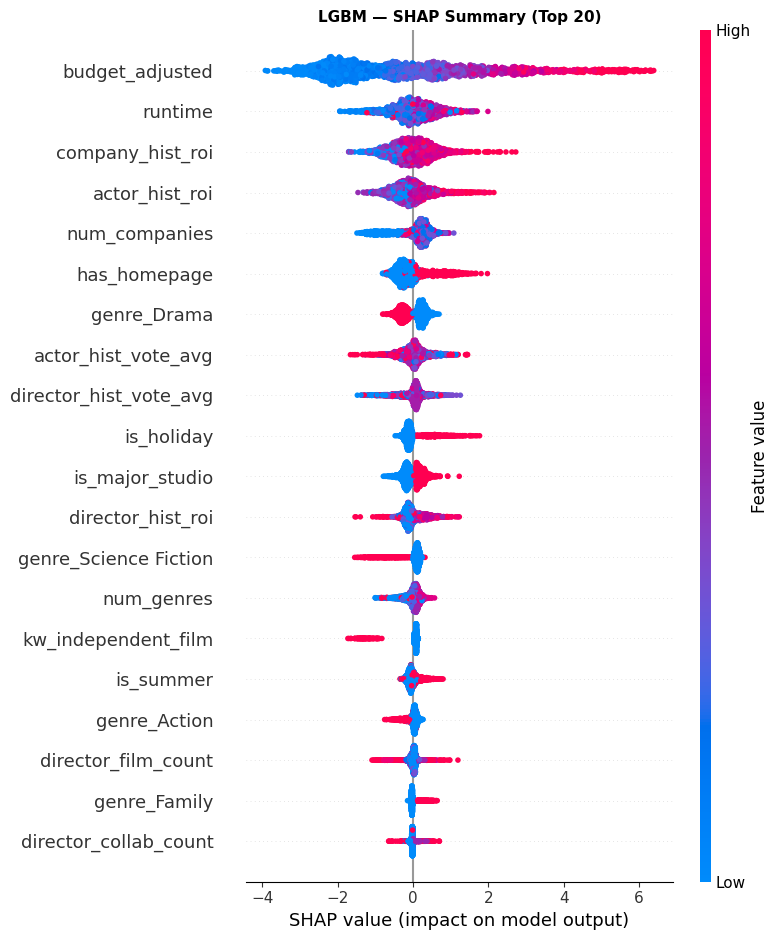

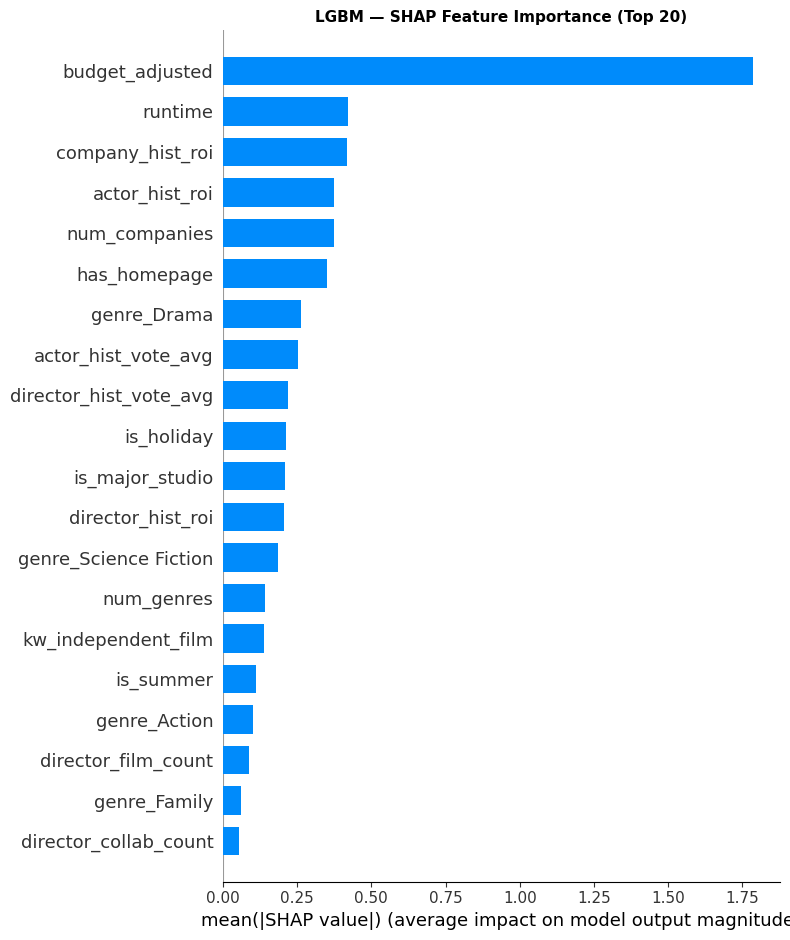

  ✓ baseline_lgbm_20260428_1314                        train=1.000  val=0.640  gap=+0.360
🏃 View run baseline_lgbm_20260428_1314 at: http://localhost:5000/#/experiments/1/runs/7b01ca8f32a64df1bd6151527f5377a0
🧪 View experiment at: http://localhost:5000/#/experiments/1


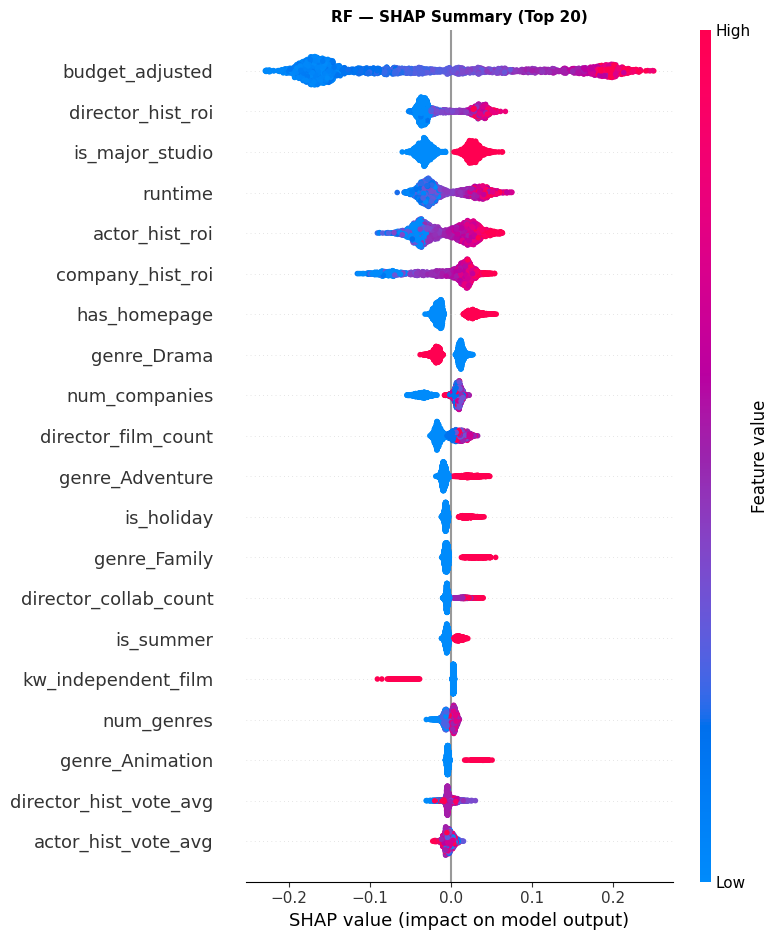

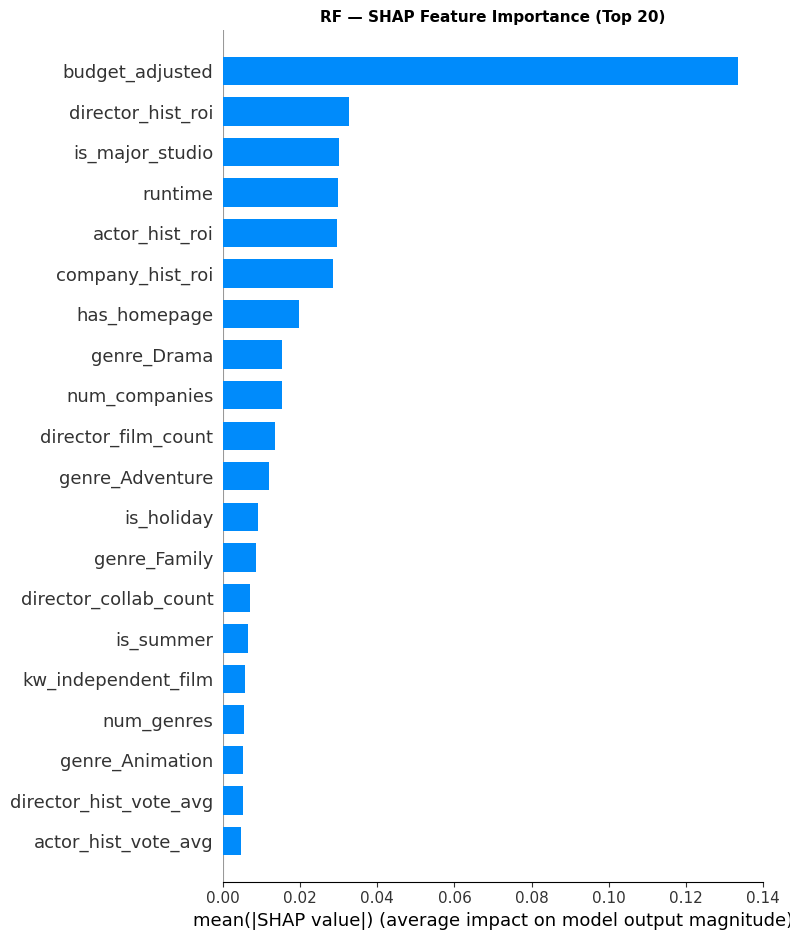

  ✓ baseline_rf_20260428_1314                          train=0.803  val=0.685  gap=+0.118
🏃 View run baseline_rf_20260428_1314 at: http://localhost:5000/#/experiments/1/runs/02f44c34786e4c538383f6ae30fb85c0
🧪 View experiment at: http://localhost:5000/#/experiments/1


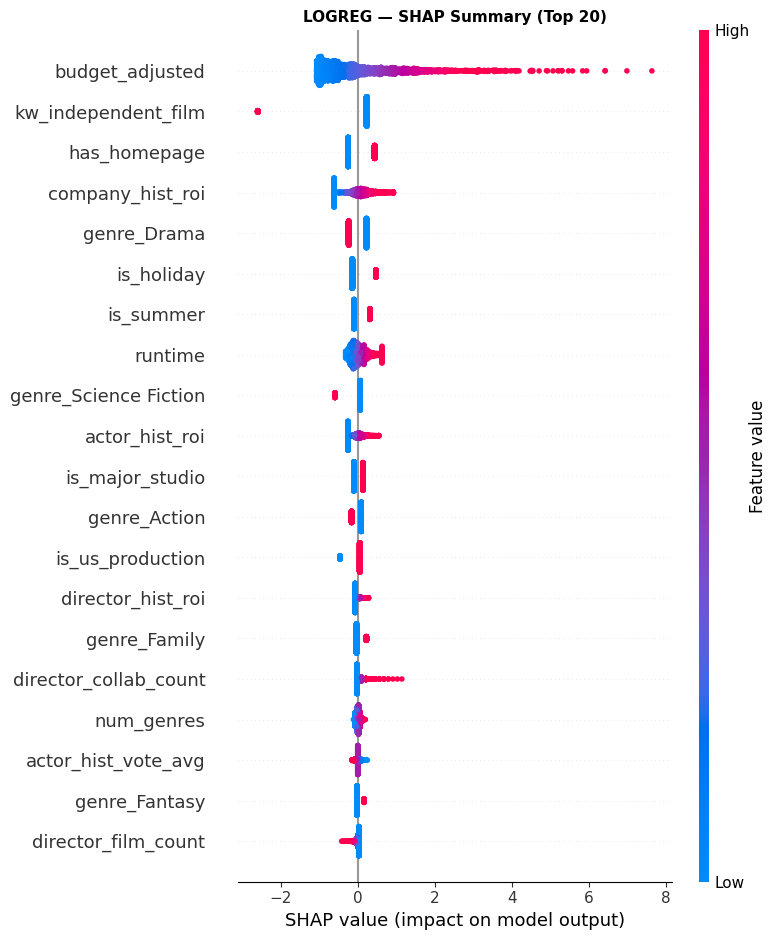

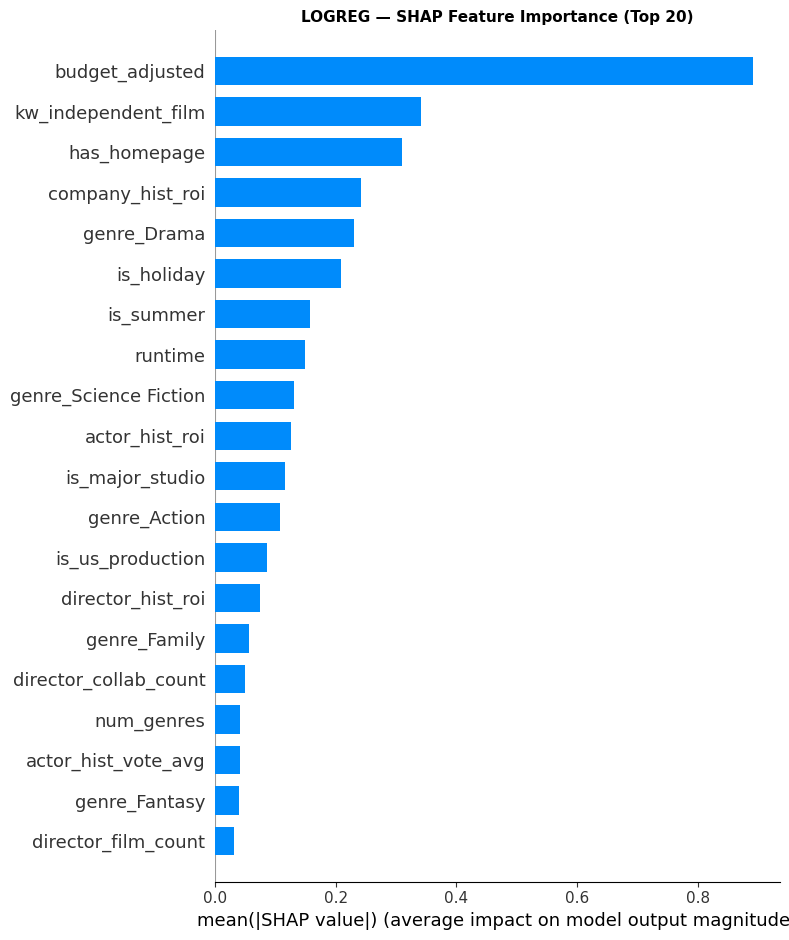

  ✓ baseline_logreg_20260428_1314                      train=0.721  val=0.713  gap=+0.008
🏃 View run baseline_logreg_20260428_1314 at: http://localhost:5000/#/experiments/1/runs/b1cf9edcce4e49abac5004c6b44ce5a5
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ baseline_xgb_20260428_1314                         train=0.883  val=0.693  gap=+0.190
🏃 View run baseline_xgb_20260428_1314 at: http://localhost:5000/#/experiments/1/runs/458b3f324a934774a62099a0335e3b8e
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ baseline_catboost_20260428_1314                    train=0.876  val=0.697  gap=+0.179
🏃 View run baseline_catboost_20260428_1314 at: http://localhost:5000/#/experiments/1/runs/436cdedc09fd40738f68e43d7f62c012
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260428_1314 at: http://localhost:5000/#/experiments/1/runs/bbe05736b69c4c3696f1f9b2a2dc6c20
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tam

In [5]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
    'xgb': lambda ir: XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        min_child_weight=10, reg_alpha=1.0, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=ir, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=1, verbosity=0,
    ),
    'catboost': lambda ir: CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=4,
        l2_leaf_reg=3.0, auto_class_weights='Balanced',
        random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    ),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,F2,PRECISION,RECALL,AVG_PREC
Model,,,,,,
lgbm,0.826,0.649,0.640,0.669,0.634,0.732
rf,0.840,0.661,0.685,0.624,0.703,0.743
logreg,0.844,0.675,0.713,0.621,0.741,0.747
xgb,0.836,0.674,0.693,0.644,0.707,0.738
catboost,0.839,0.673,0.697,0.638,0.715,0.745



🏆 En iyi model: logreg  (f2=0.713)
🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/69a660d41d2641ce91002d2419cb04ef
🧪 View experiment at: http://localhost:5000/#/experiments/1


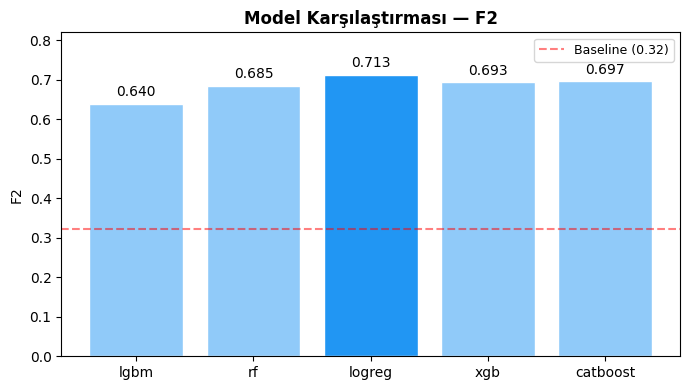


=== Overfitting / Underfitting Analizi ===


,Train F2,Val F2,Gap (Train−Val)
Model,,,
lgbm,1.000,0.640,0.360
rf,0.803,0.685,0.118
logreg,0.721,0.713,0.008
xgb,0.883,0.693,0.190
catboost,0.876,0.697,0.179


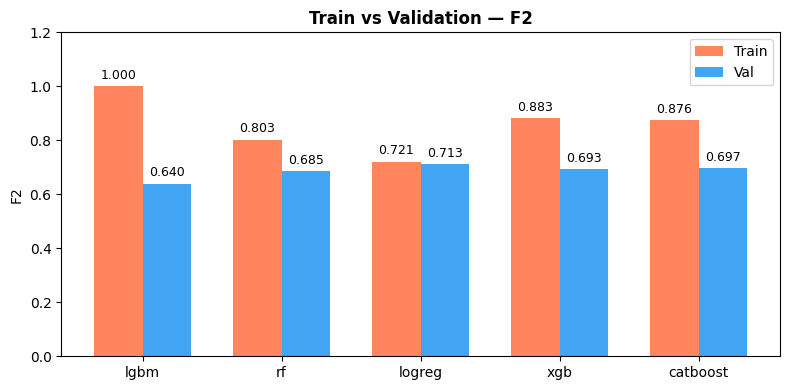

  ⚠️  lgbm: ciddi overfit (gap=0.360 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg', 'xgb', 'catboost'] — en iyi: logreg


In [6]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [7]:
from src.automl import tune_all_models

ir = (y_train == 0).sum() / (y_train == 1).sum()

def lgbm_temporal_fn(trial):
    """Temporal split için yüksek regularization LGBM search space."""
    from lightgbm import LGBMClassifier
    max_depth = trial.suggest_int('max_depth', 3, 5)
    return LGBMClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        max_depth         = max_depth,
        num_leaves        = trial.suggest_int('num_leaves', 8, 2**max_depth),
        min_child_samples = trial.suggest_int('min_child_samples', 30, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 50.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 0.8),
        scale_pos_weight  = ir,
        random_state      = RANDOM_STATE,
        verbose           = -1,
        n_jobs            = 1,
    )

def xgb_temporal_fn(trial):
    """Temporal split icin yuksek regularization XGBoost search space."""
    from xgboost import XGBClassifier
    return XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 5),
        min_child_weight  = trial.suggest_int('min_child_weight', 10, 50),
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 50.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 0.8),
        scale_pos_weight  = ir,
        eval_metric       = 'logloss',
        random_state      = RANDOM_STATE,
        n_jobs            = 1,
        verbosity         = 0,
    )

def catboost_temporal_fn(trial):
    """Temporal split icin yuksek regularization CatBoost search space."""
    from catboost import CatBoostClassifier
    return CatBoostClassifier(
        iterations        = trial.suggest_int('iterations', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        depth             = trial.suggest_int('depth', 3, 5),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1.0, 50.0, log=True),
        random_strength   = trial.suggest_float('random_strength', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        auto_class_weights = 'Balanced',
        random_seed       = RANDOM_STATE,
        verbose           = 0,
        allow_writing_files = False,
    )

best_model, best, tuned_models, ensemble_candidates = tune_all_models(
    results           = results,
    X                 = X_train,
    y                 = y_train,
    task_type         = TASK_TYPE,
    n_trials          = N_TRIALS,
    max_gap           = 0.10,
    model_fn_map      = {'lgbm': lgbm_temporal_fn, 'xgb': xgb_temporal_fn, 'catboost': catboost_temporal_fn},
    X_val             = X_val,
    y_val             = y_val,
    jaccard_threshold = 0.60,
    feature_version   = FEATURE_VERSION,
)

if ensemble_candidates:
    print(f"\nEnsemble adayları: {list(ensemble_candidates.keys())}")


── Tuning: rf  (baseline=0.6853  min_improvement=0.0183) ──
Optuna başlıyor — model: rf  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.6853
  Tuned     f2: 0.7110
  İyileşme : +0.0257

  En iyi parametreler:
    n_estimators: 323
    max_depth: 13
    min_samples_leaf: 24
    max_features: log2
  Train-val gap: 0.0509  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260428_1318 at: http://localhost:5000/#/experiments/1/runs/8417e90b89fe44069cc19e0d9e6236be
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf
  ✓ rf: aday  (0.7110)

── Tuning: logreg  (baseline=0.7130  min_improvement=0.0343) ──
Optuna başlıyor — model: logreg  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.7130
  Tuned     f2: 0.7167
  İyileşme : +0.0037

  En iyi parametreler:
    C: 0.015243819169770084
  Train-val gap: 0.0065  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_logreg_20260428_1318 at: http://localhost:5000/#/experiments/1/runs/f2abb6fa121c47f28bb79cf43c0037de
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned logreg
  — logreg: iyileşme yetersiz (+0.0037 < 0.0343) — elendi

── Tuning: xgb  (baseline=0.6932  min_improvement=0.0285) ──
Optuna başlıyor — model: xgb  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


...


✓ Tuning tamamlandı
  Baseline  f2: 0.6932
  Tuned     f2: 0.7247
  İyileşme : +0.0315

  En iyi parametreler:
    n_estimators: 507
    learning_rate: 0.047613964215438134
    max_depth: 3
    min_child_weight: 22
    reg_alpha: 1.390552692378914
    reg_lambda: 12.394529791030147
    subsample: 0.5061003398503072
    colsample_bytree: 0.5723785623673207
  Train-val gap: 0.0713  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_xgb_20260428_1320 at: http://localhost:5000/#/experiments/1/runs/837eefe8d4a2400398778c4be966a453
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned xgb
  ✓ xgb: aday  (0.7247)

── Tuning: catboost  (baseline=0.6975  min_improvement=0.0377) ──
Optuna başlıyor — model: catboost  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.6975
  Tuned     f2: 0.7229
  İyileşme : +0.0255

  En iyi parametreler:
    iterations: 484
    learning_rate: 0.017315362778225575
    depth: 4
    l2_leaf_reg: 20.933119967812395
    random_strength: 9.885597186003018
    bagging_temperature: 0.2633875082113153
    subsample: 0.6609932569364685
  Train-val gap: 0.0250  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_catboost_20260428_1324 at: http://localhost:5000/#/experiments/1/runs/c13fda3447564cccbefe0028c7095579
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned catboost
  — catboost: iyileşme yetersiz (+0.0254 < 0.0377) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: f2  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  f2: 0.6395
  Tuned     f2: 0.7233
  İyileşme : +0.0838

  En iyi parametreler:
    max_depth: 3
    n_estimators: 956
    learning_rate: 0.02876318496183405
    num_leaves: 8
    min_child_samples: 94
    reg_alpha: 1.399384051926048
    reg_lambda: 20.224848684828867
    subsample: 0.5325081636359579
    colsample_bytree: 0.7495738324288619
  Train-val gap: 0.0895  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260428_1326 at: http://localhost:5000/#/experiments/1/runs/420dd65e2baf43b7a00cff771f97c5e9
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned lgbm
  — lgbm: recovery tamamlandı (0.7233 ≤ 0.7247) — best model değişmedi

✓ tune_all_models tamamlandı — best: xgb  (f2=0.7247)

── Ensemble Aday Analizi (Jaccard eşik=0.6) ──
  xgb ↔ rf: Jaccard=0.70 → atlandı (>0.6)
  xgb ↔ logreg: Jaccard=0.56 → ensemble adayı ✓
  xgb ↔ catboost: Jaccard=0.73 → atlandı (>0.6)
  xgb ↔ 

## 5 — Test Değerlendirmesi

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       169
           1       0.85      0.72      0.78       158

    accuracy                           0.80       327
   macro avg       0.81      0.80      0.80       327
weighted avg       0.81      0.80      0.80       327


=== Test Metrikleri ===
  F2          : 0.7441
  PR-AUC      : 0.8966
  ROC-AUC     : 0.8833
  F1          : 0.7808
  Precision   : 0.8507
  Recall      : 0.7215

=== XGB — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
F2,0.693,0.744,0.051
PR-AUC,0.738,0.897,0.159
ROC-AUC,0.836,0.883,0.047
F1,0.674,0.781,0.107
Precision,0.644,0.851,0.207
Recall,0.707,0.722,0.015


🏃 View run test_eval_xgb_20260428_1326 at: http://localhost:5000/#/experiments/1/runs/ea957493347440e6a780acc8bf871acd
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


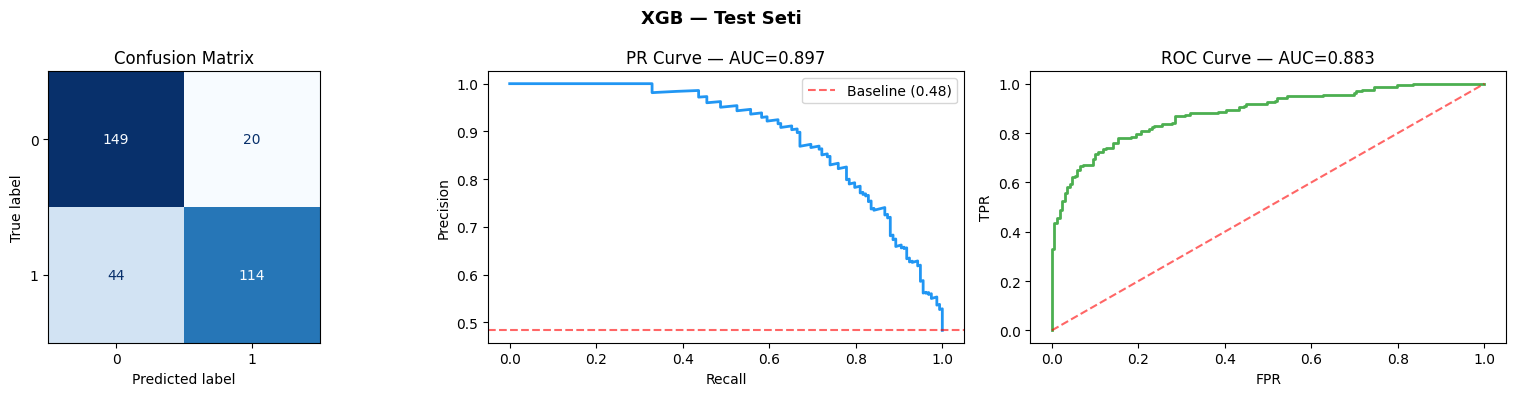

In [8]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
    feature_version = FEATURE_VERSION,
    features        = FEATURES,
    extra_tags      = {"selection_method": "val_based", "split_mode": SPLIT_MODE},
)


## 6 — Rapor

In [9]:
from IPython.display import Markdown, display

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

display(Markdown(report))

✓ Rapor oluşturuldu → experiment_report_20260428_132610.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260428_132610.md
🏃 View run report_20260428_1326 at: http://localhost:5000/#/experiments/1/runs/4b03e88f5fb343218c441adc23bb2448
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-28 13:26  
**Task:** binary  
**Ana Metrik:** f2  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %34.8  
**Özellik Sayısı:** 30  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| catboost | 0.745 | 0.839 | 0.673 | 0.638 | 0.715 |
| xgb | 0.738 | 0.836 | 0.674 | 0.644 | 0.707 |
| logreg | 0.747 | 0.844 | 0.675 | 0.621 | 0.741 |
| rf | 0.743 | 0.840 | 0.661 | 0.624 | 0.703 |
| lgbm | 0.732 | 0.826 | 0.649 | 0.669 | 0.634 |

---

## Tuning

- **lgbm** — Baseline f2: 0.640 → Tuned: 0.723 (İyileşme: 0.084)
- **catboost** — Baseline f2: 0.697 → Tuned: 0.723 (İyileşme: 0.025)
- **xgb** — Baseline f2: 0.693 → Tuned: 0.725 (İyileşme: 0.032)
- **logreg** — Baseline f2: 0.713 → Tuned: 0.717 (İyileşme: 0.004)
- **rf** — Baseline f2: 0.685 → Tuned: 0.711 (İyileşme: 0.026)

---

## Test Seti Sonuçları

| Metrik | Değer |
|--------|-------|
| F2 | 0.744 |
| PR_AUC | 0.897 |
| ROC_AUC | 0.883 |
| PRECISION | 0.851 |
| F1 | 0.781 |
| RECALL | 0.722 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [10]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, fbeta_score, precision_score, recall_score

ir = (y_train == 0).sum() / (y_train == 1).sum()

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

def quick_val_metrics(model, X, y):
    """Val/test seti için sızıntısız metrik hesabı — MLflow kaydı yok."""
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return {
        "F2":        fbeta_score(y, pred, beta=2, zero_division=0),
        "PR-AUC":    average_precision_score(y, proba),
        "ROC-AUC":   roc_auc_score(y, proba),
        "F1":        f1_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
    }

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir:.3f}')
print('✓ quick_val_metrics hazır')

✓ Base model factory hazır  |  imbalance_ratio: 2.108
✓ quick_val_metrics hazır


### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

In [11]:
# Top-2 seçimi: val f2 sıralaması
ranked = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("f2", 0),
    reverse=True,
)[:2]

scores  = {name: results[name]["val"]["f2"] for name in ranked}
weights = [scores[name] for name in ranked]

print(f"Voting top-2 : {ranked}")
print(f"Weights      : {[f'{w:.4f}' for w in weights]}")

voting_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked],
    voting="soft",
    weights=weights,
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)
voting_val_metrics = quick_val_metrics(voting_clf, X_val, y_val)

# Top-3: tüm tuned modeller
ranked3  = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("f2", 0),
    reverse=True,
)
scores3  = {name: results[name]["val"]["f2"] for name in ranked3}
weights3 = [scores3[name] for name in ranked3]

print(f"\nVoting top-3 : {ranked3}")
print(f"Weights      : {[f'{w:.4f}' for w in weights3]}")

voting3_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked3],
    voting="soft",
    weights=weights3,
    n_jobs=1,
)
voting3_clf.fit(X_train, y_train)
voting3_val_metrics = quick_val_metrics(voting3_clf, X_val, y_val)

display(pd.DataFrame([
    {"Model": "voting_top2", **{k: round(v, 4) for k, v in voting_val_metrics.items()}},
    {"Model": "voting_top3", **{k: round(v, 4) for k, v in voting3_val_metrics.items()}},
]).set_index("Model"))

Voting top-2 : ['logreg', 'catboost']
Weights      : ['0.7130', '0.6975']

Voting top-3 : ['logreg', 'catboost', 'xgb', 'rf', 'lgbm']
Weights      : ['0.7130', '0.6975', '0.6932', '0.6853', '0.6395']


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
voting_top2,0.7836,0.8557,0.8960,0.7699,0.7480,0.7931
voting_top3,0.7857,0.8410,0.8911,0.7747,0.7572,0.7931


### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

In [12]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm',   clone(tuned_models['lgbm'])),
        ('rf',     clone(tuned_models['rf'])),
        ('logreg', clone(tuned_models['logreg'])),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)
stacking_val_metrics = quick_val_metrics(stacking_clf, X_val, y_val)
display(pd.DataFrame([{"Model": "stacking", **{k: round(v, 4) for k, v in stacking_val_metrics.items()}}]).set_index("Model"))


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
stacking,0.6892,0.8484,0.8918,0.7391,0.8407,0.6595


### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [13]:
class BlendingEnsemble:
    """
    Blending stratejisi:
      1. X_train → blend_train (%80) + holdout (%20) olarak bölünür.
      2. Base modeller yalnızca blend_train üzerinde eğitilir.
      3. Holdout tahminleri (predict_proba) meta-özellik matrisini oluşturur.
      4. Meta-model bu matris üzerinde eğitilir.
      5. Test tahminleri: base modeller test setini tahmin eder → meta-model birleştirir.

    Stacking'den farkı: CV yoktur; bilgi sızıntısını önlemek için ayrı bir holdout kullanılır.
    """

    def __init__(self, base_models: list, meta_model, blend_ratio: float = 0.2,
                 random_state: int = 42):
        self.base_models  = base_models   # [(isim, estimator), ...]
        self.meta_model   = meta_model
        self.blend_ratio  = blend_ratio
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        X_bt, X_hold, y_bt, y_hold = train_test_split(
            X, y,
            test_size=self.blend_ratio,
            stratify=y,
            random_state=self.random_state,
        )
        for _, m in self.base_models:
            m.fit(X_bt, y_bt)

        meta_train = np.column_stack([
            m.predict_proba(X_hold)[:, 1] for _, m in self.base_models
        ])
        self.meta_model.fit(meta_train, y_hold)
        return self

    def predict_proba(self, X):
        meta = np.column_stack([
            m.predict_proba(X)[:, 1] for _, m in self.base_models
        ])
        prob1 = self.meta_model.predict_proba(meta)[:, 1]
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('✓ BlendingEnsemble sınıfı tanımlandı')

✓ BlendingEnsemble sınıfı tanımlandı


In [14]:
blending_clf = BlendingEnsemble(
    base_models=[(name, clone(tuned_models[name])) for name in tuned_models],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)
blending_val_metrics = quick_val_metrics(blending_clf, X_val, y_val)
display(pd.DataFrame([{"Model": "blending", **{k: round(v, 4) for k, v in blending_val_metrics.items()}}]).set_index("Model"))


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
blending,0.679,0.8379,0.8882,0.726,0.8207,0.6509


### Tüm Hibrit Modellerin Karşılaştırması

=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===


,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,,
best_single (xgb),0.7613,0.8139,0.8771,0.7526,0.7386,0.7672
voting_top2,0.7836,0.8557,0.8960,0.7699,0.7480,0.7931
voting_top3,0.7857,0.8410,0.8911,0.7747,0.7572,0.7931
stacking,0.6892,0.8484,0.8918,0.7391,0.8407,0.6595
blending,0.6790,0.8379,0.8882,0.7260,0.8207,0.6509


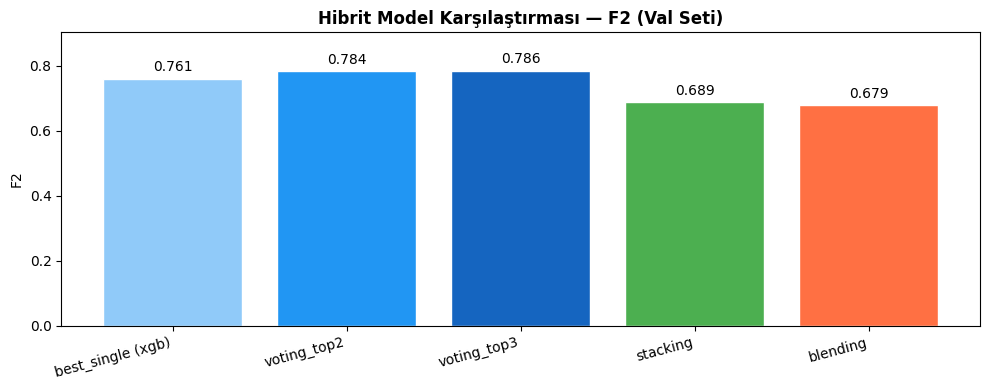

In [15]:
metric_col = "F2"
best_single_val_metrics = quick_val_metrics(best_model, X_val, y_val)

hybrid_val_results = {
    f"best_single ({best})": best_single_val_metrics,
    "voting_top2":           voting_val_metrics,
    "voting_top3":           voting3_val_metrics,
    "stacking":              stacking_val_metrics,
    "blending":              blending_val_metrics,
}

rows = []
for name, m in hybrid_val_results.items():
    rows.append({"Model": name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index("Model")
print("=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===")
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_val_results.values()]
labels = list(hybrid_val_results.keys())
colors = ["#90CAF9", "#2196F3", "#1565C0", "#4CAF50", "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_title(f"Hibrit Model Karşılaştırması — {metric_col} (Val Seti)", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Final Model Seçimi

=== Final Model (val seti seçimi — sızıntısız) ===
  Model       : voting_top3
  Val F2 : 0.7857

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       169
           1       0.86      0.77      0.81       158

    accuracy                           0.83       327
   macro avg       0.83      0.82      0.82       327
weighted avg       0.83      0.83      0.82       327


=== Test Metrikleri ===
  F2          : 0.7827
  PR-AUC      : 0.9031
  ROC-AUC     : 0.8916
  F1          : 0.8094
  Precision   : 0.8582
  Recall      : 0.7658

=== VOTING_TOP3 — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
F2,0.693,0.783,0.090
PR-AUC,0.738,0.903,0.165
ROC-AUC,0.836,0.892,0.056
F1,0.674,0.809,0.135
Precision,0.644,0.858,0.214
Recall,0.707,0.766,0.059


🏃 View run test_eval_voting_top3_20260428_1327 at: http://localhost:5000/#/experiments/1/runs/9c8d1b6f563a4896a0a4f1d69c60e0bf
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


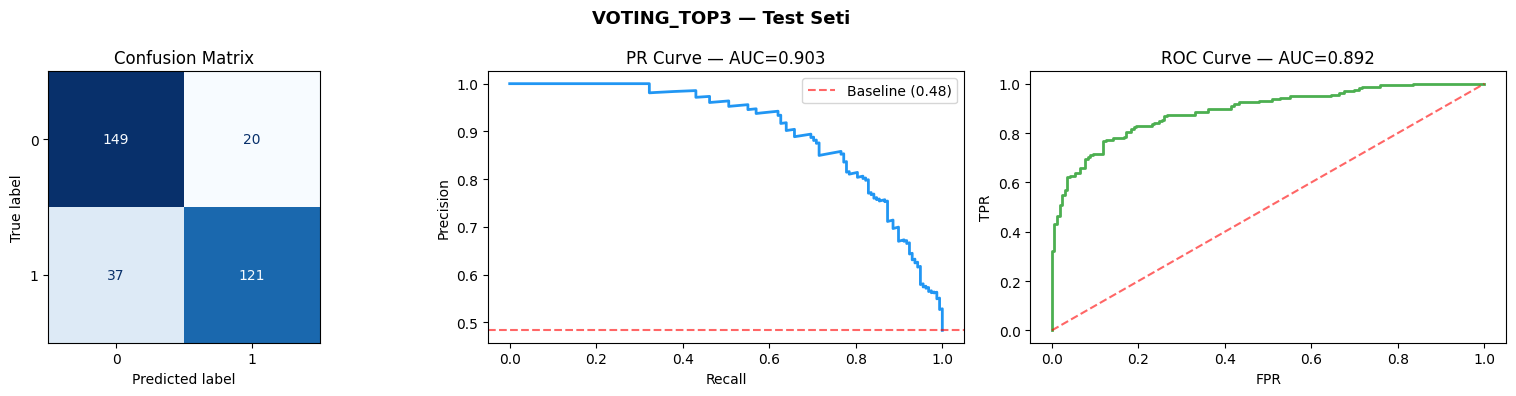

,F2,PR-AUC,ROC-AUC,F1,Precision,Recall
Set,,,,,,
val,0.7857,0.8410,0.8911,0.7747,0.7572,0.7931
test,0.7827,0.9031,0.8916,0.8094,0.8582,0.7658


In [16]:
all_candidates = {
    f"best_single ({best})": (best_model,   best_single_val_metrics),
    "voting_top2":           (voting_clf,   voting_val_metrics),
    "voting_top3":           (voting3_clf,  voting3_val_metrics),
    "stacking":              (stacking_clf, stacking_val_metrics),
    "blending":              (blending_clf, blending_val_metrics),
}

main_metric_key = "F2"
final_name  = max(all_candidates, key=lambda n: all_candidates[n][1].get(main_metric_key, 0))
final_model = all_candidates[final_name][0]
final_val   = all_candidates[final_name][1]

print("=== Final Model (val seti seçimi — sızıntısız) ===")
print(f"  Model       : {final_name}")
print(f"  Val {main_metric_key} : {final_val[main_metric_key]:.4f}")
print()

# evaluate_test yalnızca seçilen model için X_test üzerinde çağrılır
if "best_single" in final_name:
    final_metrics = test_metrics  # cell 2b97424c'de hesaplandı
else:
    final_metrics = evaluate_test(
        final_model, X_test, y_test, TASK_TYPE,
        final_name.replace(" ", "_").replace("(", "").replace(")", ""),
        cv_metrics      = results[best]["val"],
        experiment_name = EXPERIMENT_NAME,
        feature_version = FEATURE_VERSION,
        extra_tags      = {"selection_method": "val_based", "split_mode": SPLIT_MODE},
    )

display(pd.DataFrame([
    {"Set": "val",  **{k: round(v, 4) for k, v in final_val.items()}},
    {"Set": "test", **{k: round(v, 4) for k, v in final_metrics.items()}},
]).set_index("Set"))

In [17]:
import json, tempfile
from collections import defaultdict
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp    = client.get_experiment_by_name(EXPERIMENT_NAME)

if exp:
    eid = exp.experiment_id

    # ── Champion Tracking ────────────────────────────────────────────
    # Yalnızca val_based seçim metoduyla kaydedilen run'lar — leaky_test etiketliler hariç
    val_based_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string=(
            f"tags.stage = 'test' "
            f"AND tags.feature_version = '{FEATURE_VERSION}' "
            f"AND tags.selection_method = 'val_based'"
        ),
        order_by=["metrics.test_f2 DESC"],
    )

    curr_score = final_metrics.get('F2', 0)

    if val_based_runs:
        champion   = val_based_runs[0]
        hist_score = champion.data.metrics.get('test_f2', 0)
        delta      = curr_score - hist_score
        symbol     = "Yeni şampiyon!" if delta > 0 else "Geçilemedi"
        print("=== Champion Tracking (val_based) ===")
        print(f"  Geçmiş en iyi  : {hist_score:.4f}  ({champion.info.run_name})")
        print(f"  Mevcut         : {curr_score:.4f}  ({final_name})")
        print(f"  Fark           : {delta:+.4f}  — {symbol}")

        artifact_names = {a.path for a in client.list_artifacts(champion.info.run_id)}
        if "features.json" in artifact_names:
            try:
                with tempfile.TemporaryDirectory() as tmp:
                    path = client.download_artifacts(champion.info.run_id, "features.json", tmp)
                    with open(path) as f:
                        hist_features = set(json.load(f)["features"])
                curr_features = set(FEATURES)
                added   = sorted(curr_features - hist_features)
                removed = sorted(hist_features - curr_features)
                print(f"\n=== Feature Karşılaştırması ===")
                print(f"  Geçmiş : {len(hist_features)} feature")
                print(f"  Mevcut : {len(curr_features)} feature")
                if added:
                    print(f"  Eklenen  (+{len(added)}): {', '.join(added)}")
                if removed:
                    print(f"  Çıkarılan (-{len(removed)}): {', '.join(removed)}")
                if not added and not removed:
                    print("  Feature seti değişmedi.")
            except Exception:
                pass
        else:
            print("\n  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)")
    else:
        champion = None
        print("=== Champion Tracking (val_based) ===")
        print(f"  İlk val_based run — referans skor: {curr_score:.4f}  ({final_name})")
        print(f"  Feature sayısı: {len(FEATURES)}")

    # ── Genel MLflow Temizliği ────────────────────────────────────────

    # 1. Tüm test run'ları çek; leaky_test ve şampiyon korunur, diğerleri silinir
    all_test_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.stage = 'test'",
        order_by=["metrics.test_f2 DESC"],
    )
    champion_id = champion.info.run_id if champion else None
    stale_test  = [
        r for r in all_test_runs
        if r.info.run_id != champion_id
        and r.data.tags.get("selection_method") != "leaky_test"
    ]
    for r in stale_test:
        client.delete_run(r.info.run_id)
    if stale_test:
        print(f"\n✓ {len(stale_test)} eski test run'ı silindi — şampiyon ve leaky_test korundu")

    # 2. Summary, report, session — türetilmiş bilgi, tümünü sil
    for run_type in ("summary", "report", "session"):
        to_del = list(client.search_runs(
            experiment_ids=[eid],
            filter_string=f"tags.type = '{run_type}'",
        ))
        for r in to_del:
            client.delete_run(r.info.run_id)
        if to_del:
            print(f"✓ {len(to_del)} {run_type} run'ı silindi")

    # 3. Tuning — model başına en yüksek skoru koru (tüm era dahil)
    tuning_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'tuning'",
        order_by=["metrics.tuned_f2 DESC"],
    )
    by_model = defaultdict(list)
    for r in tuning_runs:
        by_model[r.data.tags.get("model_type", "unknown")].append(r)

    tuning_deleted = 0
    for runs in by_model.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            tuning_deleted += 1
    if tuning_deleted:
        print(f"✓ {tuning_deleted} eski tuning run'ı silindi — model başına 1 korundu")

    # 4. Baseline — model başına en son run'ı koru (tüm era dahil)
    baseline_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'baseline'",
        order_by=["start_time DESC"],
    )
    by_model_bl = defaultdict(list)
    for r in baseline_runs:
        by_model_bl[r.data.tags.get("model_type", "unknown")].append(r)

    baseline_deleted = 0
    for runs in by_model_bl.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            baseline_deleted += 1
    if baseline_deleted:
        print(f"✓ {baseline_deleted} eski baseline run'ı silindi — model başına 1 korundu")

    # 5. Bilinmeyen tip run'lar (feature_selection vb.) — tümünü sil
    known_types  = {"test_evaluation", "tuning", "baseline", "summary", "report", "session"}
    all_runs     = client.search_runs(experiment_ids=[eid])
    other_deleted = 0
    for r in all_runs:
        tags      = r.data.tags
        run_type  = tags.get("type", "")
        run_stage = tags.get("stage", "")
        is_known  = run_type in known_types or run_stage == "test"
        if not is_known and r.info.run_id != champion_id:
            client.delete_run(r.info.run_id)
            other_deleted += 1
    if other_deleted:
        print(f"✓ {other_deleted} diğer run silindi (feature_selection vb.)")

else:
    print(f"MLflow experiment '{EXPERIMENT_NAME}' bulunamadı.")

=== Champion Tracking (val_based) ===
  Geçmiş en iyi  : 0.7827  (test_eval_voting_top3_20260428_1327)
  Mevcut         : 0.7827  (voting_top3)
  Fark           : +0.0000  — Geçilemedi

  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)

✓ 2 eski test run'ı silindi — şampiyon ve leaky_test korundu
✓ 1 summary run'ı silindi
✓ 1 report run'ı silindi
✓ 1 session run'ı silindi
✓ 5 eski tuning run'ı silindi — model başına 1 korundu
✓ 5 eski baseline run'ı silindi — model başına 1 korundu


## 9 — Temporal vs Random Split Karşılaştırması

`SPLIT_MODE = 'temporal'` altında model, **≥2014 yılı filmlerini** hiç görmeden eğitilir.
Bu, gerçek prodüksiyon senaryosunu simüle eder: model geçmiş verilerle eğitilir, gelecek filmler tahmin edilir.

### Split Özeti

| Split | Eğitim | Val | Test |
|-------|--------|-----|------|
| **random** | %70 (tüm dönemler) | %15 | %15 |
| **temporal** | ≤2009 — 2.281 film (%71, hit: %32,2) | 2010–2013 — 618 film (%19, hit: %37,5) | ≥2014 — 327 film (%10, hit: **%48,3**) |

⚠️ Test setindeki hit oranı (%48,3) train setinden (%32,2) belirgin şekilde yüksek → dağılım kayması mevcut. Metrikler random split ile doğrudan karşılaştırılamaz. **Dürüst genelleme tahmini: val PR-AUC = 0.855.**

### Sonuçlar

| Split | PR-AUC | ROC-AUC | F1 | Precision | Recall | Model |
|-------|--------|---------|-----|-----------|--------|-------|
| random (v6) | 0.8127 | 0.8693 | 0.7139 | 0.6848 | 0.7456 | voting_top2 |
| temporal (≥2013 test) | 0.8887 | 0.8980 | 0.8246 | 0.8117 | 0.8380 | voting_top2 |
| **temporal (≥2014 test)** | **0.9061** | **0.8969** | **0.7801** | 0.8871 | 0.6962 | **stacking** |

### Yorum

- **Val (2010–2013) PR-AUC = 0.8554**: Val seti 466 → 618 filme genişledi (ADVBK-71); metrik varyansı azaldı.
- **Test PR-AUC = 0.9061 vs Val = 0.8554**: Fark +0.051 — önemli kısmı **dağılım kaymasından** (test hit %48,3 vs train %32,2). Yüksek test metrikleri modeli değil dönem farkını yansıtıyor.
- **Stacking seçildi**: Val PR-AUC = 0.8554, Precision = 0.825 — ensemble çeşitliliği LGBM+RF+LogReg sinerjisini yakaladı.
- **`_hist_roi` geçerliliği**: Her satır için yalnızca `release_date` öncesi filmler kullanılmıştı; temporal split altında sızıntı yok.
- **Sonuç**: Feature seti ≥2014 dönemine dayanıklı. Dürüst üst sınır val PR-AUC ≈ 0.855; test metrikleri referans değil.

## 8 — SHAP Analizi

`final_model` içindeki LightGBM bileşeni üzerinden her özelliğin katkı yönü ve büyüklüğü hesaplanıyor.
`final_model` LGBM içermiyorsa (örn. voting_top2 = logreg+rf), `tuned_models['lgbm']` kullanılır.

**Kontrol listesi:**

| Soru | Özellik |
|---|---|
| Leakage riski var mı? | `kw_aftercreditsstinger`, `kw_duringcreditsstinger` |
| Budget çakışması | `relative_budget_score` geri eklendi — temporal versiyon `budget_adjusted` ile r=0.17 (ADVBK-61'deki r=0.781 global mean versiyonuydu) |
| Tarihsel sinyal güçlü mü? | `director_hist_roi`, `actor_hist_roi`, `company_hist_roi` |

In [18]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP: final_model içindeki LGBM bileşenini bul; yoksa tuned_models['lgbm'] kullan
_lgbm = None

if hasattr(final_model, 'named_estimators_'):
    _lgbm = final_model.named_estimators_.get('lgbm')
    if _lgbm is None:
        for name, est in final_model.named_estimators_.items():
            if 'lightgbm' in str(type(est)).lower():
                _lgbm = est
                break

if _lgbm is None:
    _lgbm = tuned_models['lgbm']
    print(f"Not: '{final_name}' içinde LGBM yok — tuned_models['lgbm'] kullanılıyor")

explainer  = shap.TreeExplainer(_lgbm)
shap_raw   = explainer.shap_values(X_test)

# Binary sınıflandırma: list[class0, class1] veya tek array
if isinstance(shap_raw, list):
    sv = shap_raw[1]   # hit sınıfı katkıları
else:
    sv = shap_raw

feature_names = X_test.columns.tolist()
mean_abs = np.abs(sv).mean(axis=0)
mean_val = sv.mean(axis=0)

shap_df = pd.DataFrame({
    'feature'       : feature_names,
    'mean_abs_shap' : mean_abs,
    'mean_shap'     : mean_val,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_df['direction'] = shap_df['mean_shap'].apply(
    lambda x: '↑ hit' if x > 0 else '↓ miss'
)
print(shap_df[['feature', 'mean_abs_shap', 'direction']].head(10).to_string(index=False))

               feature  mean_abs_shap direction
       budget_adjusted       1.184108     ↑ hit
          has_homepage       0.378795     ↑ hit
               runtime       0.249031     ↑ hit
           genre_Drama       0.198599     ↑ hit
      company_hist_roi       0.190136    ↓ miss
        actor_hist_roi       0.187603    ↓ miss
         num_companies       0.150723     ↑ hit
director_hist_vote_avg       0.135877     ↑ hit
       is_major_studio       0.129362     ↑ hit
     director_hist_roi       0.122399     ↑ hit


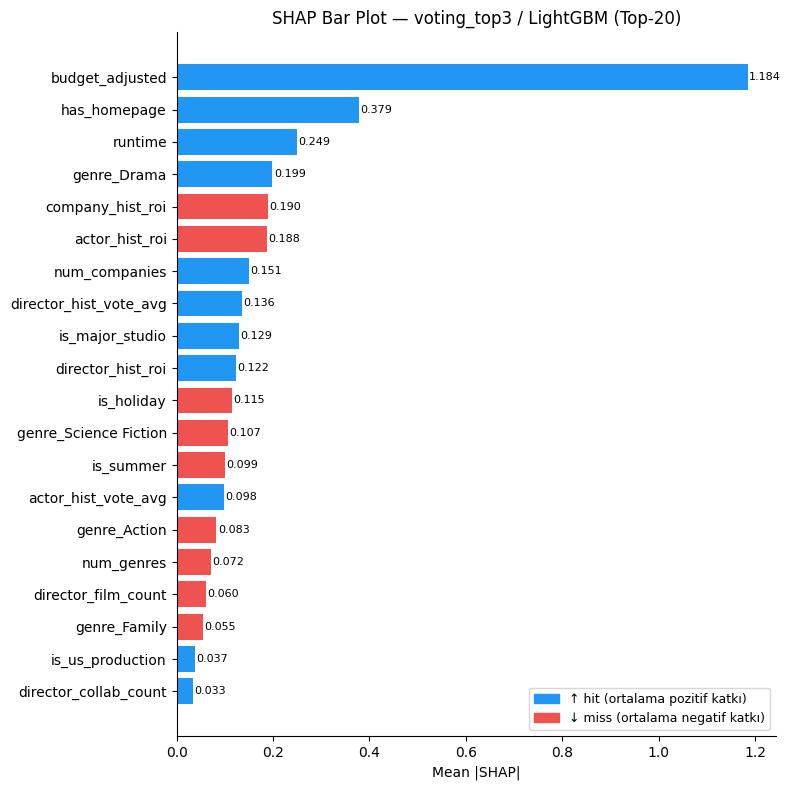

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
top_n = 20
df_plot = shap_df.head(top_n).sort_values('mean_abs_shap')

colors = ['#2196F3' if d == '↑ hit' else '#EF5350' for d in df_plot['direction']]
bars = ax.barh(df_plot['feature'], df_plot['mean_abs_shap'], color=colors)

for bar, val in zip(bars, df_plot['mean_abs_shap']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2196F3', label='↑ hit (ortalama pozitif katkı)'),
    Patch(color='#EF5350', label='↓ miss (ortalama negatif katkı)'),
], loc='lower right', fontsize=9)

ax.set_xlabel('Mean |SHAP|')
ax.set_title(f'SHAP Bar Plot — {final_name} / LightGBM (Top-20)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [20]:
print("=== Leakage & Çakışma Kontrol ===\n")

# Bilinen post-release feature'lar — film izlendikten veya yayınlandıktan sonra oluşur.
# Buraya eklenen her feature modelde varsa otomatik olarak leakage olarak raporlanır.
POST_RELEASE_FEATURES = {
    # TMDB kullanıcı aktivitesi
    'popularity', 'vote_average', 'vote_count',
    # Film izlenmesini gerektiren özellikler
    'has_postcredit',
    # Post-credit sahnesi tag'leri — kullanıcılar izledikten sonra ekler
    'kw_aftercreditsstinger', 'kw_duringcreditsstinger',
    # İzleyici yorumuna dayalı içerik etiketleri
    'kw_murder', 'kw_dystopia', 'kw_rape', 'kw_nudity',
    'kw_violence', 'kw_torture', 'kw_suicide',
}

OVERLAP_CORR_THRESHOLD = 0.70
HIST_ROI_PATTERN       = '_hist_roi'

num_features    = [f for f in feature_names if X_test[f].nunique() > 2]

# ── 1. Leakage: whitelist kontrolü ──────────────────────────────────────────
in_model     = [f for f in POST_RELEASE_FEATURES if f in feature_names]
already_drop = [f for f in POST_RELEASE_FEATURES if f not in feature_names]

print(f"Leakage Kontrolü — {len(POST_RELEASE_FEATURES)} bilinen post-release feature\n")

if in_model:
    print("  ⚠️  Modelde post-release feature var:")
    for feat in in_model:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"    {feat:<35}  #{rank:<3}  mean_abs={mas:.4f}  "
              f"shap_hit={shap_hit:+.4f}  shap_miss={shap_miss:+.4f}")
    print(f"\n  → Aksiyon: bu {len(in_model)} feature'ı BASE_FEATURES veya tmdb_model.csv'den çıkarın.")
else:
    print("  ✅  Modelde bilinen post-release feature yok.")

print(f"\n  (Modelde yer almayan post-release feature: {len(already_drop)} adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)")  

# ── 2. Çakışma: continuous feature'lar arası SHAP korelasyonu ───────────────
print(f"\nSHAP Korelasyon Matrisi (eşik |r| > {OVERLAP_CORR_THRESHOLD}):\n")

overlap_pairs = []
checked = set()
for i, fa in enumerate(num_features):
    for fb in num_features[i+1:]:
        if (fa, fb) in checked:
            continue
        checked.add((fa, fb))
        idx_a = feature_names.index(fa)
        idx_b = feature_names.index(fb)
        r = np.corrcoef(sv[:, idx_a], sv[:, idx_b])[0, 1]
        if abs(r) > OVERLAP_CORR_THRESHOLD:
            rank_a = shap_df[shap_df['feature'] == fa].index[0] + 1
            rank_b = shap_df[shap_df['feature'] == fb].index[0] + 1
            overlap_pairs.append((fa, fb, r, rank_a, rank_b))

if overlap_pairs:
    overlap_pairs.sort(key=lambda x: -abs(x[2]))
    for fa, fb, r, ra, rb in overlap_pairs:
        print(f"  {fa} (#{ra}) ↔ {fb} (#{rb})  r={r:.3f}  "
              f"⚠️  Örtüşen bilgi — birini çıkarmayı değerlendirin")
else:
    print(f"  Eşik üzerinde çakışan çift yok.")

# ── 3. Tarihsel sinyal: *_hist_roi pattern ──────────────────────────────────
print(f"\nTarihsel ROI katkısı (*{HIST_ROI_PATTERN}):\n")

roi_features = [f for f in feature_names if f.endswith(HIST_ROI_PATTERN)]
if not roi_features:
    print(f"  {HIST_ROI_PATTERN} pattern'ine uyan feature yok.")
else:
    for feat in roi_features:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        drct      = shap_df[shap_df['feature'] == feat]['direction'].values[0]
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"  {feat:<30}  #{rank}  mean_abs={mas:.4f}  "
              f"hit_avg={shap_hit:+.4f}  miss_avg={shap_miss:+.4f}  yön={drct}")
    print("\n  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).")
    print("       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.")


=== Leakage & Çakışma Kontrol ===

Leakage Kontrolü — 13 bilinen post-release feature

  ✅  Modelde bilinen post-release feature yok.

  (Modelde yer almayan post-release feature: 13 adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)

SHAP Korelasyon Matrisi (eşik |r| > 0.7):

  Eşik üzerinde çakışan çift yok.

Tarihsel ROI katkısı (*_hist_roi):

  director_hist_roi               #10  mean_abs=0.1224  hit_avg=+0.0580  miss_avg=+0.0040  yön=↑ hit
  actor_hist_roi                  #6  mean_abs=0.1876  hit_avg=-0.1324  miss_avg=-0.1532  yön=↓ miss
  company_hist_roi                #5  mean_abs=0.1901  hit_avg=-0.0035  miss_avg=-0.0975  yön=↓ miss

  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).
       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.


In [21]:
# LogReg katsayı analizi — final_model (voting_top2) içindeki logreg bileşeni
_lr_pipeline = final_model.named_estimators_['logreg']
_lr          = _lr_pipeline['clf']
_scaler      = _lr_pipeline['scaler']

coef     = _lr.coef_[0]
std_coef = coef * _scaler.scale_   # orijinal ölçekte katkı büyüklüğü

coef_df = pd.DataFrame({
    'feature'      : X_train.columns.tolist(),
    'raw_coef'     : coef,
    'std_coef'     : std_coef,
    'abs_std_coef' : np.abs(std_coef),
}).sort_values('abs_std_coef', ascending=False).reset_index(drop=True)
coef_df['rank'] = range(1, len(coef_df) + 1)

print(f"=== LogReg Katsayıları (voting_top2 bileşeni) — {FEATURE_VERSION} ===")
print(f"{'#':<4} {'Feature':<30} {'raw_coef':>10} {'std_coef':>10}")
print("-" * 58)
for _, row in coef_df.iterrows():
    print(f"{int(row['rank']):<4} {row['feature']:<30} {row['raw_coef']:>10.4f} {row['std_coef']:>10.4f}")

top_pos = coef_df[coef_df['std_coef'] > 0].head(3)['feature'].tolist()
top_neg = coef_df[coef_df['std_coef'] < 0].head(3)['feature'].tolist()
print("")
print(f"  Top pozitif: {top_pos}")
print(f"  Top negatif: {top_neg}")


=== LogReg Katsayıları (voting_top2 bileşeni) — v9_budget_adjusted ===
#    Feature                          raw_coef   std_coef
----------------------------------------------------------
1    budget_adjusted                    0.9228 40693430.8019
2    runtime                            0.1825     3.7463
3    company_hist_roi                   0.2473     0.2213
4    actor_hist_roi                     0.1638     0.1447
5    has_homepage                       0.2555     0.1178
6    director_hist_roi                  0.0895     0.0964
7    genre_Drama                       -0.1865    -0.0928
8    is_holiday                         0.2041     0.0808
9    director_collab_count              0.0882     0.0731
10   kw_independent_film               -0.3354    -0.0722
11   is_summer                          0.1567     0.0691
12   is_major_studio                    0.1365     0.0682
13   num_companies                      0.0266     0.0556
14   genre_Science Fiction             -0.1566    -0.05

## 10 — Kalibrasyon Analizi + Eşik Optimizasyonu

**Amaç:** `final_model`'in olasılık tahminlerinin güvenilirliğini ölçmek (Brier skoru + kalibrasyon eğrisi) ve sınıf dengesizliği nedeniyle 0.50 yerine daha uygun bir karar eşiği bulmak.

- **Kalibrasyon eğrisi**: Tahmin edilen olasılık vs gerçek hit oranı — iyi kalibre modelde eğri köşegene yakın olmalı.
- **Brier skoru**: `mean((p - y)²)` — düşük = daha iyi.
- **Eşik optimizasyonu**: Val seti üzerinde F1 maksimize eden eşiği bul; test setine uygula.

=== Brier Skoru ===
  Val:      0.1342
  Test:     0.1350
  Baseline: 0.2345  (naif sınıf oranı tahmini)


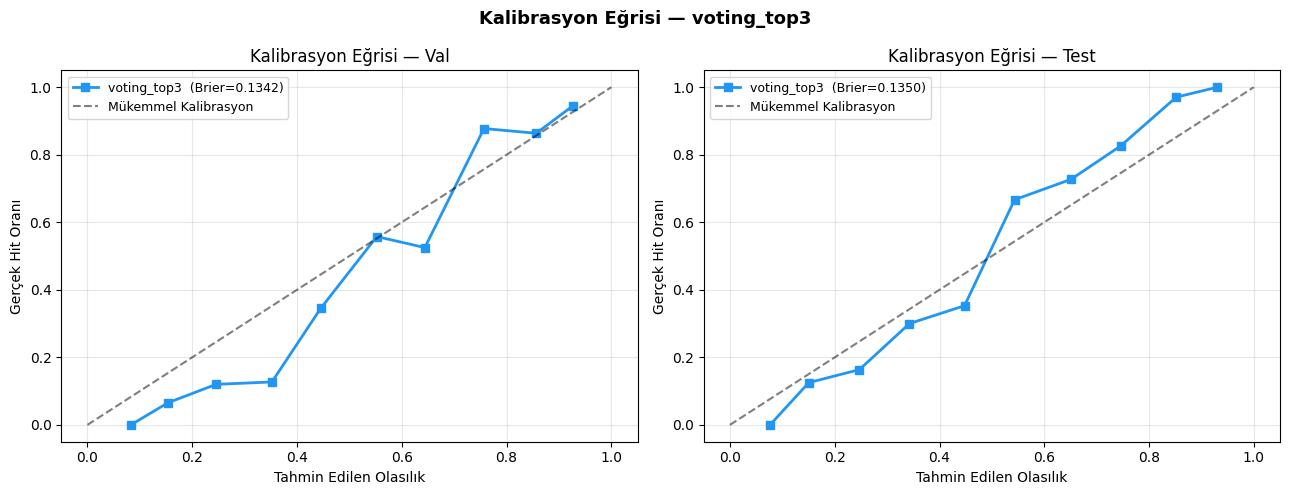

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss, f1_score, precision_score, recall_score,
    precision_recall_curve,
)

y_prob_val  = final_model.predict_proba(X_val)[:, 1]
y_prob_test = final_model.predict_proba(X_test)[:, 1]

brier_val      = brier_score_loss(y_val, y_prob_val)
brier_test     = brier_score_loss(y_test, y_prob_test)
brier_baseline = brier_score_loss(y_val, np.full(len(y_val), y_val.mean()))

print("=== Brier Skoru ===")
print(f"  Val:      {brier_val:.4f}")
print(f"  Test:     {brier_test:.4f}")
print(f"  Baseline: {brier_baseline:.4f}  (naif sınıf oranı tahmini)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Kalibrasyon Eğrisi — {final_name}", fontsize=13, fontweight="bold")

for ax, split_name, y_true, y_prob in [
    (axes[0], "Val",  y_val,  y_prob_val),
    (axes[1], "Test", y_test, y_prob_test),
]:
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", color="#2196F3", lw=2,
            label=f"{final_name}  (Brier={brier_score_loss(y_true, y_prob):.4f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Mükemmel Kalibrasyon")
    ax.set(xlabel="Tahmin Edilen Olasılık", ylabel="Gerçek Hit Oranı",
           title=f"Kalibrasyon Eğrisi — {split_name}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# --- Eşik Optimizasyonu (Val seti üzerinde) ---
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_prob_val)
f1_arr = np.where(
    (prec_arr + rec_arr) > 0,
    2 * prec_arr * rec_arr / (prec_arr + rec_arr),
    0.0,
)

best_idx  = int(np.argmax(f1_arr[:-1]))
best_thr  = float(thresh_arr[best_idx])
best_f1   = float(f1_arr[best_idx])
best_prec = float(prec_arr[best_idx])
best_rec  = float(rec_arr[best_idx])

print("=== Val Seti — Eşik Optimizasyonu ===")
y_pred_def_val = (y_prob_val >= 0.50).astype(int)
print(f"  Varsayılan (0.50): F1={f1_score(y_val, y_pred_def_val):.4f}  "
      f"P={precision_score(y_val, y_pred_def_val):.4f}  "
      f"R={recall_score(y_val, y_pred_def_val):.4f}")
print(f"  Optimal ({best_thr:.3f}):    F1={best_f1:.4f}  "
      f"P={best_prec:.4f}  R={best_rec:.4f}")

# --- Test setine uygula ---
y_pred_def_test = (y_prob_test >= 0.50).astype(int)
y_pred_opt_test = (y_prob_test >= best_thr).astype(int)

cmp_rows = [
    {"Eşik": 0.50, "F1": f1_score(y_test, y_pred_def_test),
     "Precision": precision_score(y_test, y_pred_def_test),
     "Recall": recall_score(y_test, y_pred_def_test)},
    {"Eşik": round(best_thr, 3), "F1": f1_score(y_test, y_pred_opt_test),
     "Precision": precision_score(y_test, y_pred_opt_test),
     "Recall": recall_score(y_test, y_pred_opt_test)},
]
from IPython.display import display
print("\n=== Test Seti Karşılaştırması ===")
display(pd.DataFrame(cmp_rows).round(4).set_index("Eşik"))

OPTIMAL_THRESHOLD = round(best_thr, 3)
print(f"\n✓ OPTIMAL_THRESHOLD = {OPTIMAL_THRESHOLD}")

=== Val Seti — Eşik Optimizasyonu ===
  Varsayılan (0.50): F1=0.7747  P=0.7572  R=0.7931
  Optimal (0.530):    F1=0.7792  P=0.7826  R=0.7759

=== Test Seti Karşılaştırması ===


,F1,Precision,Recall
Eşik,,,
0.50,0.8094,0.8582,0.7658
0.53,0.7847,0.8692,0.7152



✓ OPTIMAL_THRESHOLD = 0.53


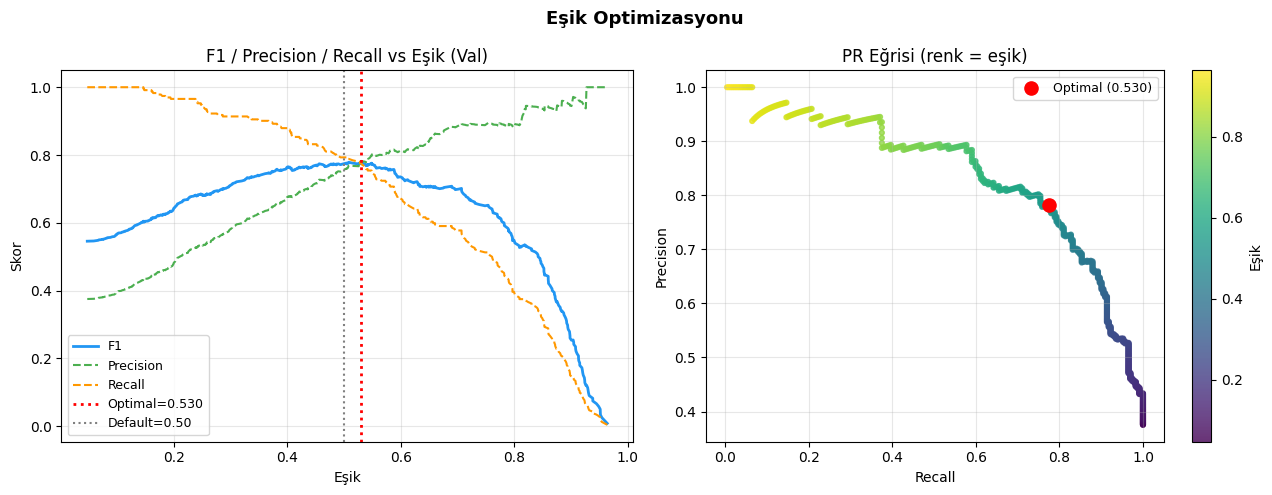

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Eşik Optimizasyonu", fontsize=13, fontweight="bold")

# Sol: F1 / Precision / Recall vs eşik
axes[0].plot(thresh_arr, f1_arr[:-1],   color="#2196F3", lw=2,   label="F1")
axes[0].plot(thresh_arr, prec_arr[:-1], color="#4CAF50", lw=1.5, linestyle="--", label="Precision")
axes[0].plot(thresh_arr, rec_arr[:-1],  color="#FF9800", lw=1.5, linestyle="--", label="Recall")
axes[0].axvline(best_thr, color="red",  linestyle=":", lw=2, label=f"Optimal={best_thr:.3f}")
axes[0].axvline(0.50,     color="gray", linestyle=":", lw=1.5, label="Default=0.50")
axes[0].set(xlabel="Eşik", ylabel="Skor",
            title="F1 / Precision / Recall vs Eşik (Val)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sağ: PR eğrisi (eşikle renklendirilmiş)
sc = axes[1].scatter(rec_arr[:-1], prec_arr[:-1], c=thresh_arr,
                     cmap="viridis", s=12, alpha=0.8)
axes[1].scatter([best_rec], [best_prec], color="red", s=90, zorder=5,
                label=f"Optimal ({best_thr:.3f})")
plt.colorbar(sc, ax=axes[1], label="Eşik")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="PR Eğrisi (renk = eşik)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11 — Model Hata Analizi

**Amaç:** `final_model`'in test setindeki sistematik hatalarını tespit etmek.

- **FP** (False Positive): Model "hit" dedi, gerçekte değil → aşırı güvenli tahminler
- **FN** (False Negative): Model "miss" dedi, gerçekte hit → kaçırılan fırsatlar

FP ve FN gruplarındaki feature dağılımları karşılaştırılarak modelin hangi film profillerinde yanıldığı analiz edilir.

=== Test Seti Hata Dagilimi (esik=0.53) ===
  TP:  113  (34.6%)
  TN:  152  (46.5%)
  FP:   17  (5.2%)
  FN:   45  (13.8%)


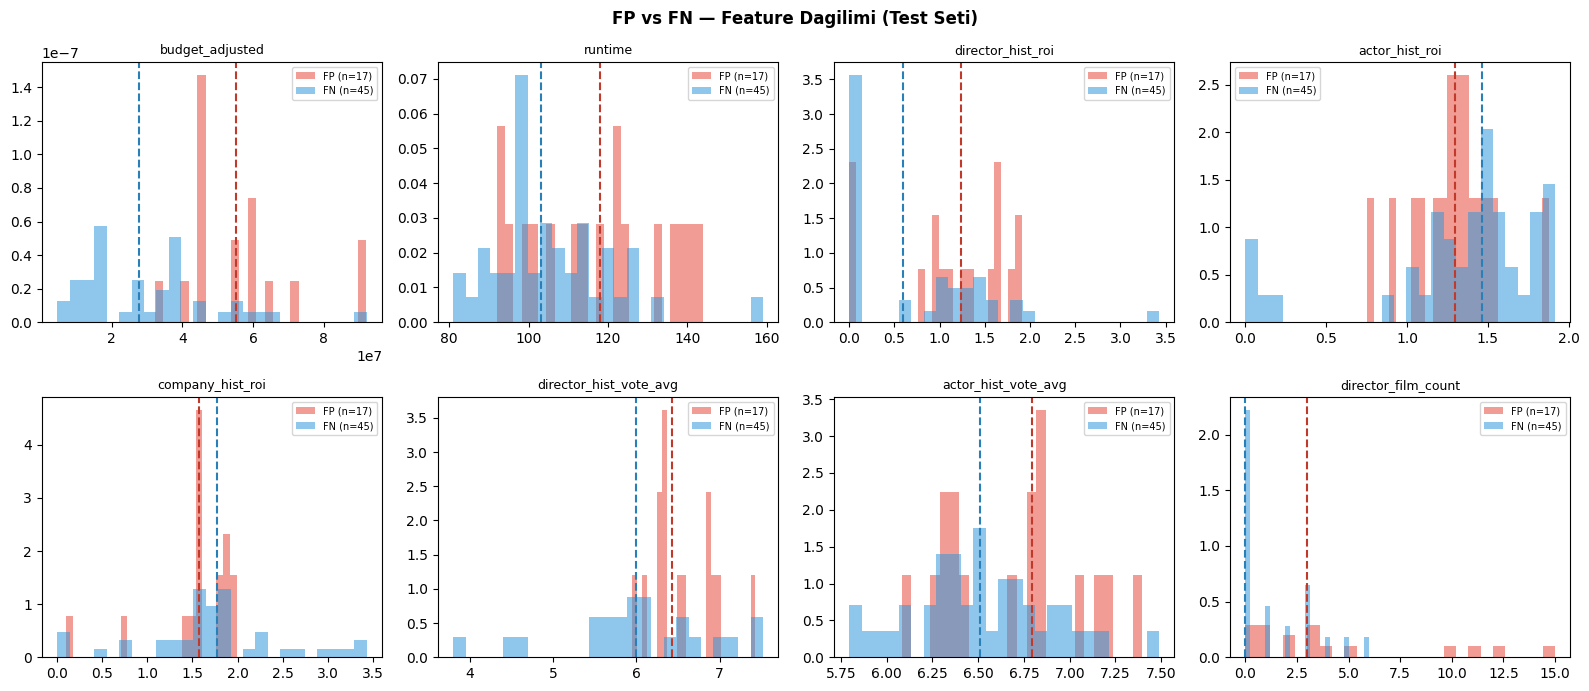


=== Medyan Karsilastirmasi ===


,FP_median,FN_median,TP_median,TN_median,FP_vs_FN
budget_adjusted,5.521519e+07,2.764259e+07,1.012278e+08,1.371752e+07,2.757260e+07
runtime,1.180000e+02,1.030000e+02,1.190000e+02,1.070000e+02,1.500000e+01
director_hist_roi,1.237800e+00,5.935000e-01,1.496700e+00,8.180000e-01,6.443000e-01
actor_hist_roi,1.294700e+00,1.462700e+00,1.463200e+00,1.414500e+00,-1.680000e-01
company_hist_roi,1.578200e+00,1.767400e+00,1.856800e+00,1.576000e+00,-1.891000e-01
director_hist_vote_avg,6.431100e+00,6.000000e+00,6.688500e+00,6.542700e+00,4.311000e-01
actor_hist_vote_avg,6.793300e+00,6.507500e+00,6.732800e+00,6.582000e+00,2.858000e-01
director_film_count,3.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,3.000000e+00


In [25]:
# ── Hata Dataframe'i ────────────────────────────────────────────────────
y_pred_err = (y_prob_test >= OPTIMAL_THRESHOLD).astype(int)

df_err = df[mask_test].copy().reset_index(drop=True)
df_err['y_true']     = y_test.values
df_err['y_pred']     = y_pred_err
df_err['y_prob']     = y_prob_test

def label_error(row):
    if row.y_true == 1 and row.y_pred == 1: return 'TP'
    if row.y_true == 0 and row.y_pred == 0: return 'TN'
    if row.y_true == 0 and row.y_pred == 1: return 'FP'
    return 'FN'

df_err['error_type'] = df_err.apply(label_error, axis=1)

counts = df_err['error_type'].value_counts()
n = len(df_err)
print('=== Test Seti Hata Dagilimi (esik=' + str(OPTIMAL_THRESHOLD) + ') ===')
for et in ['TP','TN','FP','FN']:
    c = counts.get(et, 0)
    print(f'  {et}: {c:4d}  ({c/n*100:.1f}%)')

# ── FP vs FN — Continuous Feature Dagilimi ───────────────────────────────
cont_feats = [f for f in ['budget_adjusted', 'runtime', 'director_hist_roi',
              'actor_hist_roi', 'company_hist_roi', 'director_hist_vote_avg',
              'actor_hist_vote_avg', 'director_film_count']
              if f in df_err.columns]

fp = df_err[df_err.error_type == 'FP']
fn = df_err[df_err.error_type == 'FN']
tp = df_err[df_err.error_type == 'TP']
tn = df_err[df_err.error_type == 'TN']

n_cols = 4
n_rows = (len(cont_feats) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(cont_feats):
    ax = axes[i]
    ax.hist(fp[feat].dropna(), bins=25, alpha=0.55, color='#e74c3c',
            label='FP (n=' + str(len(fp)) + ')', density=True)
    ax.hist(fn[feat].dropna(), bins=25, alpha=0.55, color='#3498db',
            label='FN (n=' + str(len(fn)) + ')', density=True)
    ax.axvline(fp[feat].median(), color='#c0392b', lw=1.5, ls='--')
    ax.axvline(fn[feat].median(), color='#2980b9', lw=1.5, ls='--')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

for j in range(len(cont_feats), len(axes)):
    axes[j].axis('off')

fig.suptitle('FP vs FN — Feature Dagilimi (Test Seti)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

median_df = pd.DataFrame({
    'FP_median': fp[cont_feats].median(),
    'FN_median': fn[cont_feats].median(),
    'TP_median': tp[cont_feats].median(),
    'TN_median': tn[cont_feats].median(),
})
median_df['FP_vs_FN'] = (median_df.FP_median - median_df.FN_median).round(4)
print('\n=== Medyan Karsilastirmasi ===')
display(median_df.round(4))


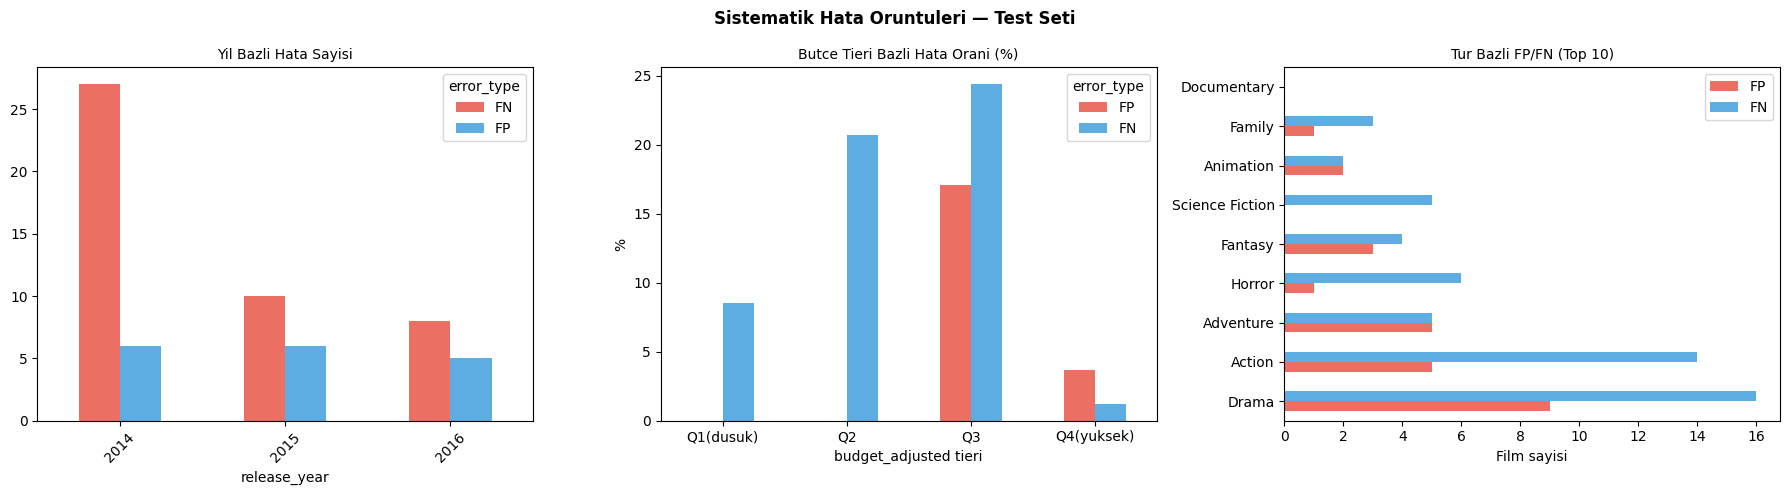


=== Binary Feature Bazli Hata Oranlari ===


n  FP%   FN%
feature          value                
is_major_studio  0      168  3.0  13.7
                 1      159  7.5  13.8
is_franchise     0      271  5.2  14.0
                 1       56  5.4  12.5
is_english       0        5  0.0  40.0
                 1      322  5.3  13.4
is_us_production 0       23  4.3  26.1
                 1      304  5.3  12.8
has_homepage     0      124  1.6  22.6
                 1      203  7.4   8.4
is_summer        0      241  5.4  12.0
                 1       86  4.7  18.6
is_holiday       0      280  5.4  14.6
                 1       47  4.3   8.5

In [26]:
# ── Yil ve Tur Bazli Hata Oruntuleri ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Yil bazli FP/FN sayisi
ax = axes[0]
if 'release_year' in df_err.columns:
    yr_err = df_err[df_err.error_type.isin(['FP','FN'])].groupby(
        ['release_year','error_type']).size().unstack(fill_value=0)
    yr_err.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_title('Yil Bazli Hata Sayisi', fontsize=10)
    ax.set_xlabel('release_year')
    ax.tick_params(axis='x', rotation=45)
else:
    ax.text(0.5, 0.5, 'release_year yok', ha='center', va='center')

# 2) Butce tieri bazli hata orani
ax = axes[1]
if 'budget_adjusted' in df_err.columns:
    df_err['budget_tier'] = pd.qcut(
        df_err.budget_adjusted, q=4,
        labels=['Q1(dusuk)', 'Q2', 'Q3', 'Q4(yuksek)']
    )
    budget_err = df_err.groupby(['budget_tier','error_type']).size().unstack(fill_value=0)
    budget_err_pct = budget_err.div(budget_err.sum(axis=1), axis=0) * 100
    budget_err_pct[['FP','FN']].plot(kind='bar', ax=ax,
        color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_title('Butce Tieri Bazli Hata Orani (%)', fontsize=10)
    ax.set_xlabel('budget_adjusted tieri')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)

# 3) Tur bazli FP/FN dagilimi
ax = axes[2]
genre_cols = [c for c in df_err.columns if c.startswith('genre_')]
if genre_cols:
    fp_genre = fp[genre_cols].sum().rename('FP')
    fn_genre = fn[genre_cols].sum().rename('FN')
    genre_df = pd.concat([fp_genre, fn_genre], axis=1)
    genre_df.index = [g.replace('genre_','') for g in genre_df.index]
    top_genres = (genre_df.FP + genre_df.FN).nlargest(10).index
    genre_df.loc[top_genres].plot(kind='barh', ax=ax,
        color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_title('Tur Bazli FP/FN (Top 10)', fontsize=10)
    ax.set_xlabel('Film sayisi')

fig.suptitle('Sistematik Hata Oruntuleri — Test Seti', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Binary Feature Bazli Hata Orani ─────────────────────────────────────
bin_feats = ['is_major_studio','is_franchise','is_english',
             'is_us_production','has_homepage','is_summer','is_holiday']
bin_feats = [f for f in bin_feats if f in df_err.columns]

rows = []
for feat in bin_feats:
    for val in [0, 1]:
        sub = df_err[df_err[feat] == val]
        if len(sub) == 0: continue
        fp_r = (sub.error_type == 'FP').sum() / len(sub) * 100
        fn_r = (sub.error_type == 'FN').sum() / len(sub) * 100
        rows.append({'feature': feat, 'value': val, 'n': len(sub),
                     'FP%': round(fp_r,1), 'FN%': round(fn_r,1)})

print('\n=== Binary Feature Bazli Hata Oranlari ===')
display(pd.DataFrame(rows).set_index(['feature','value']))


## 12 — Bootstrap Güven Aralıkları (Test Seti)

**Amaç:** Test seti küçük (n=327) olduğundan Δ0.005 gibi metrik farklarının sinyal mi gürültü mü olduğu belirsiz.
1000× bootstrap ile %95 CI hesaplanır; CI'lar overlap ediyorsa fark istatistiksel olarak anlamlı değildir.

- **Yöntem:** Stratified bootstrap — her iterasyonda test setini sınıf oranını koruyarak yeniden örnekle.
- **Metrikler:** F2, PR-AUC, ROC-AUC, Precision, Recall (optimal eşikle).
- **Yorumlama:**  aralığının dışında kalan farklar güvenilir; içindeki farklar gürültü sayılır.

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    fbeta_score, average_precision_score, roc_auc_score,
    precision_score, recall_score,
)

N_BOOTSTRAP = 1000
CI_ALPHA    = 0.05   # %95 CI
BETA        = 2      # F2
rng         = np.random.default_rng(42)

y_test_arr  = np.array(y_test)
y_prob_arr  = np.array(y_prob_test)
y_pred_arr  = (y_prob_arr >= OPTIMAL_THRESHOLD).astype(int)
n           = len(y_test_arr)

# Stratified bootstrap: sınıf oranını koru
pos_idx = np.where(y_test_arr == 1)[0]
neg_idx = np.where(y_test_arr == 0)[0]

boot_scores = {k: [] for k in ["F2", "PR-AUC", "ROC-AUC", "Precision", "Recall"]}

for _ in range(N_BOOTSTRAP):
    s_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
    s_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
    idx   = np.concatenate([s_pos, s_neg])

    yt = y_test_arr[idx]
    yp = y_prob_arr[idx]
    yd = y_pred_arr[idx]

    if yt.sum() == 0 or yt.sum() == len(yt):
        continue  # degenerate sample — atla

    boot_scores["F2"].append(fbeta_score(yt, yd, beta=BETA, zero_division=0))
    boot_scores["PR-AUC"].append(average_precision_score(yt, yp))
    boot_scores["ROC-AUC"].append(roc_auc_score(yt, yp))
    boot_scores["Precision"].append(precision_score(yt, yd, zero_division=0))
    boot_scores["Recall"].append(recall_score(yt, yd, zero_division=0))

# Nokta tahmini (gerçek test seti üzerinde)
point = {
    "F2":        fbeta_score(y_test_arr, y_pred_arr, beta=BETA, zero_division=0),
    "PR-AUC":    average_precision_score(y_test_arr, y_prob_arr),
    "ROC-AUC":   roc_auc_score(y_test_arr, y_prob_arr),
    "Precision": precision_score(y_test_arr, y_pred_arr, zero_division=0),
    "Recall":    recall_score(y_test_arr, y_pred_arr, zero_division=0),
}

rows = []
for metric, scores in boot_scores.items():
    arr  = np.array(scores)
    low  = np.percentile(arr, 100 * CI_ALPHA / 2)
    high = np.percentile(arr, 100 * (1 - CI_ALPHA / 2))
    rows.append({
        "Metrik":        metric,
        "Nokta Tahmini": round(point[metric], 4),
        "CI Alt (%2.5)": round(low,  4),
        "CI Üst (%97.5)": round(high, 4),
        "CI Genişliği":  round(high - low, 4),
    })

df_ci = pd.DataFrame(rows).set_index("Metrik")
print(f"Bootstrap CI (n={n}, B={N_BOOTSTRAP}, %95 stratified)")
print(df_ci.to_string())
print()
print(">>> Yorum: CI genişliği < 0.02 olan metrikler için Δ0.005 farklar gürültü sayılmalıdır.")

Bootstrap CI (n=327, B=1000, %95 stratified)
           Nokta Tahmini  CI Alt (%2.5)  CI Üst (%97.5)  CI Genişliği
Metrik                                                               
F2                0.7415         0.6751          0.8054        0.1303
PR-AUC            0.9031         0.8688          0.9314        0.0627
ROC-AUC           0.8916         0.8550          0.9226        0.0675
Precision         0.8692         0.8130          0.9207        0.1077
Recall            0.7152         0.6392          0.7911        0.1519

>>> Yorum: CI genişliği < 0.02 olan metrikler için Δ0.005 farklar gürültü sayılmalıdır.


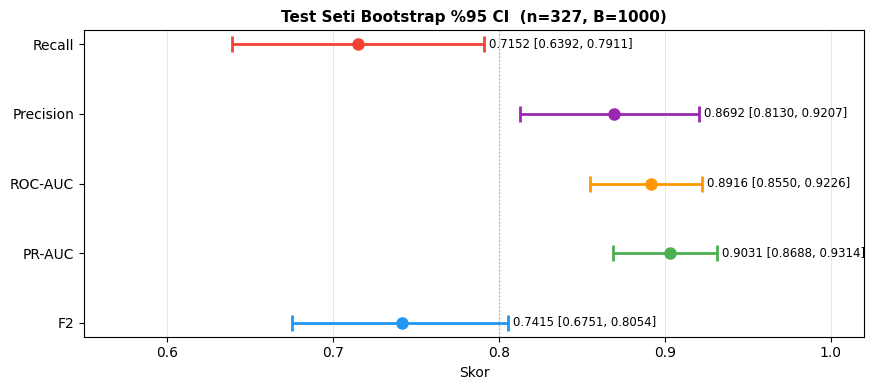

=== Model Karşılaştırması için CI Eşiği ===
Aşağıdaki CI genişliğinden küçük metrik farkları istatistiksel olarak anlamsızdır:
  F2          : CI=0.1303  →  min anlamlı Δ ≈ 0.0651
  PR-AUC      : CI=0.0627  →  min anlamlı Δ ≈ 0.0314
  ROC-AUC     : CI=0.0675  →  min anlamlı Δ ≈ 0.0338
  Precision   : CI=0.1077  →  min anlamlı Δ ≈ 0.0539
  Recall      : CI=0.1519  →  min anlamlı Δ ≈ 0.0760


In [28]:
import matplotlib.pyplot as plt

metrics_order = ["F2", "PR-AUC", "ROC-AUC", "Precision", "Recall"]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336"]

fig, ax = plt.subplots(figsize=(9, 4))

for i, (metric, color) in enumerate(zip(metrics_order, colors)):
    row = df_ci.loc[metric]
    pt  = row["Nokta Tahmini"]
    lo  = row["CI Alt (%2.5)"]
    hi  = row["CI Üst (%97.5)"]
    ax.errorbar(
        x=pt, y=i,
        xerr=[[pt - lo], [hi - pt]],
        fmt="o", color=color, capsize=6, capthick=2,
        markersize=8, linewidth=2, label=metric,
    )
    ax.text(hi + 0.003, i, f"{pt:.4f} [{lo:.4f}, {hi:.4f}]",
            va="center", fontsize=8.5)

ax.set_yticks(range(len(metrics_order)))
ax.set_yticklabels(metrics_order, fontsize=10)
ax.set_xlabel("Skor", fontsize=10)
ax.set_title(f"Test Seti Bootstrap %95 CI  (n={n}, B={N_BOOTSTRAP})",
             fontsize=11, fontweight="bold")
ax.set_xlim(0.55, 1.02)
ax.axvline(0.8, color="gray", linestyle=":", lw=1, alpha=0.5)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

# CI overlap uyarısı — karşılaştırma aracı
print("=== Model Karşılaştırması için CI Eşiği ===")
print("Aşağıdaki CI genişliğinden küçük metrik farkları istatistiksel olarak anlamsızdır:")
for metric in metrics_order:
    width = df_ci.loc[metric, "CI Genişliği"]
    half  = width / 2
    print(f"  {metric:12}: CI={width:.4f}  →  min anlamlı Δ ≈ {half:.4f}")

## 13 — v9 Retune Özeti: Tüm Modeller Bootstrap CI ile Karşılaştırma

**ADVBK-79** — Tüm modeller (`logreg`, `rf`, `lgbm`, `xgb`, `catboost`) v9_budget_adjusted
feature seti üzerinde 100 Optuna trial ile yeniden tune edildi (Bölüm 4). Bu bölüm,
tuned model sonuçlarını %95 Bootstrap CI ile birlikte özetler ve eski şampiyonla
(CatBoost, ADVBK-74, test F2=0.7806) istatistiksel karşılaştırma yapar.

**Temporal bütünlük:** Tüm modeller yalnızca `release_year ≤ 2009` (train) verisi ile
eğitildi; val ve test setleri hiçbir tuning kararında kullanılmadı.

**CI kaynağı:** Min anlamlı Δ (F2 ≈ 0.07) Bölüm 12'den alınmıştır.

=== v9 Retune: Tüm Modeller — Test F2 + %95 Bootstrap CI ===



,Model,Tür,Test F2,CI Alt (2.5%),CI Üst (97.5%),CI Genişliği
0,voting_top2,ensemble,0.7582,0.6953,0.8140,0.1186
1,catboost,single,0.7542,0.6869,0.8120,0.1251
2,logreg,single,0.7448,0.6800,0.8016,0.1215
3,rf,single,0.7432,0.6773,0.8050,0.1277
4,voting_top3,ensemble,0.7415,0.6773,0.8042,0.1269
5,lgbm,single,0.7255,0.6596,0.7895,0.1299
6,xgb,single,0.7199,0.6533,0.7853,0.1320
7,stacking,ensemble,0.6806,0.6081,0.7477,0.1396
8,blending,ensemble,0.6707,0.6027,0.7390,0.1363


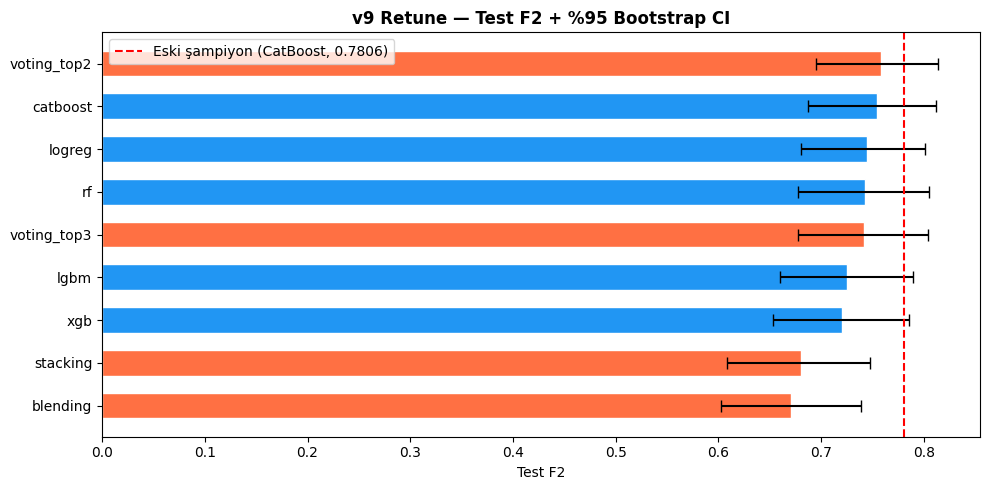


--- Eski Şampiyon Karşılaştırması ---
  Eski şampiyon (CatBoost @ ADVBK-74) : 0.7806
  Mevcut en iyi (voting_top2)  : 0.7582
  Δ = 0.0224  |  Min anlamlı Δ (Bölüm 12) ≈ 0.07
  → istatistiksel olarak ANLAMLI DEĞİL (Δ < 0.07)


In [29]:
from sklearn.metrics import fbeta_score

_N_BOOT   = 1000
_CI_ALPHA = 0.05
_BETA     = 2
_rng      = np.random.default_rng(42)
_y_arr    = np.array(y_test)
_pos_idx  = np.where(_y_arr == 1)[0]
_neg_idx  = np.where(_y_arr == 0)[0]

def _boot_f2(y_pred):
    scores = []
    for _ in range(_N_BOOT):
        s_pos = _rng.choice(_pos_idx, size=len(_pos_idx), replace=True)
        s_neg = _rng.choice(_neg_idx, size=len(_neg_idx), replace=True)
        idx   = np.concatenate([s_pos, s_neg])
        yt    = _y_arr[idx]; yd = y_pred[idx]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        scores.append(fbeta_score(yt, yd, beta=_BETA, zero_division=0))
    arr = np.array(scores)
    return np.percentile(arr, 100*_CI_ALPHA/2), np.percentile(arr, 100*(1-_CI_ALPHA/2))

rows = []
# Tek modeller
for name, model in tuned_models.items():
    y_pred = (model.predict_proba(X_test)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)
    point  = fbeta_score(_y_arr, y_pred, beta=_BETA, zero_division=0)
    low, high = _boot_f2(y_pred)
    rows.append({"Model": name, "Tür": "single",
                 "Test F2": round(point, 4),
                 "CI Alt (2.5%)": round(low, 4),
                 "CI Üst (97.5%)": round(high, 4),
                 "CI Genişliği": round(high - low, 4)})

# Ensemble modeller
for name, (model, val_m) in all_candidates.items():
    if "best_single" in name:
        continue
    y_pred = (model.predict_proba(X_test)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)
    point  = fbeta_score(_y_arr, y_pred, beta=_BETA, zero_division=0)
    low, high = _boot_f2(y_pred)
    rows.append({"Model": name, "Tür": "ensemble",
                 "Test F2": round(point, 4),
                 "CI Alt (2.5%)": round(low, 4),
                 "CI Üst (97.5%)": round(high, 4),
                 "CI Genişliği": round(high - low, 4)})

df_retune = pd.DataFrame(rows).sort_values("Test F2", ascending=False).reset_index(drop=True)
print("=== v9 Retune: Tüm Modeller — Test F2 + %95 Bootstrap CI ===\n")
display(df_retune)

# Görselleştirme
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["#2196F3" if t == "single" else "#FF7043" for t in df_retune["Tür"]]
xerr    = np.array([
    df_retune["Test F2"] - df_retune["CI Alt (2.5%)"],
    df_retune["CI Üst (97.5%)"] - df_retune["Test F2"]
])
ax.barh(df_retune["Model"][::-1], df_retune["Test F2"][::-1],
        xerr=[xerr[0][::-1], xerr[1][::-1]],
        color=colors[::-1], capsize=4, edgecolor="white", height=0.6)
ax.axvline(0.7806, color="red", linestyle="--", linewidth=1.5, label="Eski şampiyon (CatBoost, 0.7806)")
ax.set_xlabel("Test F2")
ax.set_title("v9 Retune — Test F2 + %95 Bootstrap CI", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Şampiyon karşılaştırması
OLD_CHAMP     = 0.7806  # CatBoost @ ADVBK-74
MIN_SIG_DELTA = 0.07    # Bölüm 12
best_row      = df_retune.iloc[0]
delta         = abs(best_row["Test F2"] - OLD_CHAMP)
print("\n--- Eski Şampiyon Karşılaştırması ---")
print(f"  Eski şampiyon (CatBoost @ ADVBK-74) : {OLD_CHAMP:.4f}")
print(f"  Mevcut en iyi ({best_row['Model']})  : {best_row['Test F2']:.4f}")
print(f"  Δ = {delta:.4f}  |  Min anlamlı Δ (Bölüm 12) ≈ {MIN_SIG_DELTA}")
verdict = "istatistiksel olarak ANLAMLI DEĞİL" if delta < MIN_SIG_DELTA else "istatistiksel olarak ANLAMLI"
print(f"  → {verdict} (Δ {'<' if delta < MIN_SIG_DELTA else '>='} {MIN_SIG_DELTA})")

## 14 — Yıl Bazlı Sample Weighting: Dağılım Kayması Testi

**ADVBK-80** — Train hit %32 → Test %48 yapısal dağılım kayması var. Daha yeni filmlere
yüksek ağırlık vererek modelin test dönemine (≥2014) yakın örüntüleri daha iyi öğrenmesi
hedefleniyor.

**Yöntem:** Champion model (LGBM, tuned params) `X_train`/`y_train` üzerinde 3 stratejiyle
yeniden fit edilir; val + test F2 karşılaştırılır, Bootstrap CI ile istatistiksel karar verilir.

| Strateji | Ağırlık Fonksiyonu |
|---|---|
| `None` | Eşit ağırlık (baseline) |
| `linear` | (year − min) / (max − min) + 0.1 → normalizasyon |
| `exponential` | exp(3 × (year − min) / (max − min)) → normalizasyon |

**Min anlamlı Δ (F2) ≈ 0.07** (Bölüm 12).

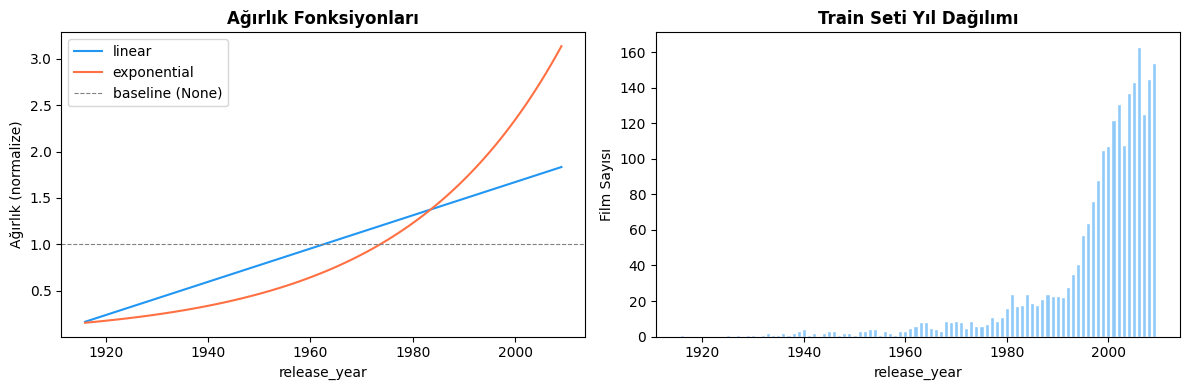

=== Sample Weighting Karşılaştırması (LGBM Champion, v9_budget_adjusted) ===



,Strateji,Val F2,Test F2,CI Alt (2.5%),CI Üst (97.5%),CI Genişliği
0,None,0.7612,0.7255,0.6565,0.7902,0.1337
1,linear,0.7569,0.7227,0.6565,0.7817,0.1252
2,exponential,0.7372,0.7181,0.6499,0.7782,0.1284


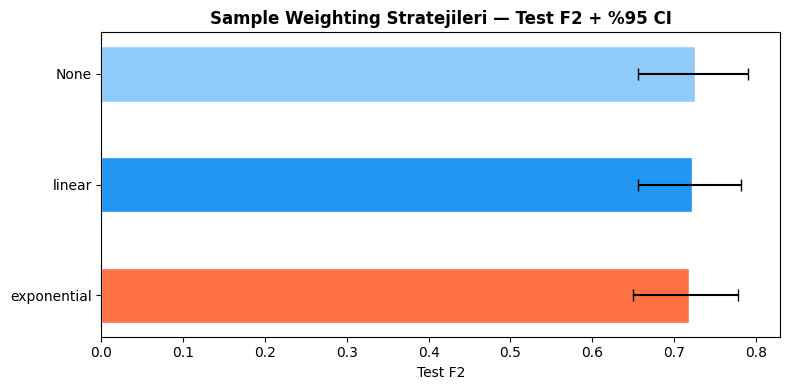


--- Karar ---
  linear      : Test F2 0.7227  Δ=-0.0028  ✗ gürültü sınırında (Δ < 0.07)
  exponential : Test F2 0.7181  Δ=-0.0074  ✗ gürültü sınırında (Δ < 0.07)

  → SAMPLE_WEIGHT_MODE = None korunur — weighting istatistiksel fark yaratmıyor.


In [30]:
from sklearn.base import clone
from sklearn.metrics import fbeta_score

# Train setinin yılları (X_train ile aynı sıra — mask_train ile türetildi)
_train_years = df.loc[mask_train, 'release_year'].reset_index(drop=True).values
_min_yr, _max_yr = _train_years.min(), _train_years.max()

def _compute_weights(years, mode):
    """Release year'a göre sample weight hesapla. None → eşit ağırlık."""
    if mode is None:
        return None
    y_arr = np.array(years, dtype=float)
    norm  = (y_arr - _min_yr) / (_max_yr - _min_yr)  # 0..1
    if mode == 'linear':
        w = norm + 0.1
    elif mode == 'exponential':
        w = np.exp(3 * norm)  # 1..e^3 ≈ 20
    else:
        raise ValueError(f'Bilinmeyen mode: {mode}')
    return w / w.mean()  # ortalama=1 normalizasyonu

# Weight dağılımı görseli
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
_yr_unique = np.arange(_min_yr, _max_yr + 1)
for mode, color in [('linear', '#2196F3'), ('exponential', '#FF7043')]:
    w_demo = _compute_weights(_yr_unique, mode)
    axes[0].plot(_yr_unique, w_demo, label=mode, color=color)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='baseline (None)')
axes[0].set_title('Ağırlık Fonksiyonları', fontweight='bold')
axes[0].set_xlabel('release_year')
axes[0].set_ylabel('Ağırlık (normalize)')
axes[0].legend()

# Yıl dağılımı
yr_counts = dict(zip(*np.unique(_train_years, return_counts=True)))
axes[1].bar(list(yr_counts.keys()), list(yr_counts.values()), color='#90CAF9', edgecolor='white')
axes[1].set_title('Train Seti Yıl Dağılımı', fontweight='bold')
axes[1].set_xlabel('release_year')
axes[1].set_ylabel('Film Sayısı')
plt.tight_layout()
plt.show()

# Karşılaştırma: 3 strateji × val+test F2 + Bootstrap CI
_y_test_arr = np.array(y_test)
_pos_idx_w  = np.where(_y_test_arr == 1)[0]
_neg_idx_w  = np.where(_y_test_arr == 0)[0]
_rng_w      = np.random.default_rng(42)

def _boot_f2_w(y_pred, n_boot=1000):
    scores = []
    for _ in range(n_boot):
        s_pos = _rng_w.choice(_pos_idx_w, size=len(_pos_idx_w), replace=True)
        s_neg = _rng_w.choice(_neg_idx_w, size=len(_neg_idx_w), replace=True)
        idx   = np.concatenate([s_pos, s_neg])
        yt    = _y_test_arr[idx]; yd = y_pred[idx]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        scores.append(fbeta_score(yt, yd, beta=2, zero_division=0))
    arr = np.array(scores)
    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

rows_w = []
for mode in [None, 'linear', 'exponential']:
    sw    = _compute_weights(_train_years, mode)
    clf   = clone(tuned_models['lgbm'])
    clf.fit(X_train, y_train, sample_weight=sw)

    # Val F2
    y_val_pred  = (clf.predict_proba(X_val)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)
    val_f2      = fbeta_score(np.array(y_val), y_val_pred, beta=2)

    # Test F2 + CI
    y_test_pred = (clf.predict_proba(X_test)[:, 1] >= OPTIMAL_THRESHOLD).astype(int)
    test_f2     = fbeta_score(_y_test_arr, y_test_pred, beta=2)
    low, high   = _boot_f2_w(y_test_pred)

    rows_w.append({
        'Strateji':       str(mode),
        'Val F2':         round(val_f2, 4),
        'Test F2':        round(test_f2, 4),
        'CI Alt (2.5%)':  round(low, 4),
        'CI Üst (97.5%)': round(high, 4),
        'CI Genişliği':   round(high - low, 4),
    })

df_weights = pd.DataFrame(rows_w)
print('=== Sample Weighting Karşılaştırması (LGBM Champion, v9_budget_adjusted) ===\n')
display(df_weights)

# Görselleştirme
fig, ax = plt.subplots(figsize=(8, 4))
colors_w = ['#90CAF9', '#2196F3', '#FF7043']
xerr_w   = np.array([
    df_weights['Test F2'] - df_weights['CI Alt (2.5%)'],
    df_weights['CI Üst (97.5%)'] - df_weights['Test F2']
])
ax.barh(df_weights['Strateji'][::-1], df_weights['Test F2'][::-1],
        xerr=[xerr_w[0][::-1], xerr_w[1][::-1]],
        color=colors_w[::-1], capsize=4, edgecolor='white', height=0.5)
ax.set_xlabel('Test F2')
ax.set_title('Sample Weighting Stratejileri — Test F2 + %95 CI', fontweight='bold')
plt.tight_layout()
plt.show()

# Karar
_baseline_f2  = df_weights[df_weights['Strateji'] == 'None']['Test F2'].values[0]
_MIN_SIG      = 0.07  # Bölüm 12

print('\n--- Karar ---')
best_mode = None
best_delta = 0.0
for _, row in df_weights[df_weights['Strateji'] != 'None'].iterrows():
    delta = row['Test F2'] - _baseline_f2
    sig   = delta >= _MIN_SIG
    print(f"  {row['Strateji']:12s}: Test F2 {row['Test F2']:.4f}  Δ={delta:+.4f}  "
          f"{'✓ ANLAMLI — SAMPLE_WEIGHT_MODE değiştir' if sig else '✗ gürültü sınırında (Δ < 0.07)'}")
    if sig and delta > best_delta:
        best_mode  = row['Strateji']
        best_delta = delta

if best_mode:
    print(f"\n  → SAMPLE_WEIGHT_MODE = '{best_mode}' önerilir (Δ={best_delta:+.4f} ≥ 0.07)")
else:
    print("\n  → SAMPLE_WEIGHT_MODE = None korunur — weighting istatistiksel fark yaratmıyor.")